## Setup

In [1]:
import matplotlib.pyplot as plt

# Global settings for A0 Poster readability
plt.rcParams.update({
    'font.size': 24,          # Base font size
    'axes.titlesize': 28,     # Plot title
    'axes.labelsize': 26,     # X and Y axis labels
    'xtick.labelsize': 22,    # X axis numbers
    'ytick.labelsize': 22,    # Y axis numbers
    'legend.fontsize': 16,    # Legend text
    'lines.linewidth': 3,     # Thicker line plots
    'lines.markersize': 12    # Larger data points/scatter dots
})

In [2]:
import sys
import os  
sys.path.append('/Users/eduardmrug/Documents/Honours research/main_program/')
import cobra
import thermo_flux
from thermo_flux.io import load_excel as ex
from thermo_flux.core.model import ThermoModel
from equilibrator_api import  Q_
import pandas as pd
from thermo_flux.io import helper_load as hl
import numpy as np
from matplotlib import pyplot as plt

In [3]:
INPUT_FOLDER='datafiles/'

In [4]:
# Load a Cobra model
model = cobra.io.load_model('e_coli_core')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2836280
Academic license 2836280 - for non-commercial use only - registered to e.___@student.rug.nl


In [5]:
from cobra import Reaction, Metabolite

def expand_model(model):
    # ---------------------------------------------------------
    # 1. DEFINE NEW METABOLITES
    # ---------------------------------------------------------
    # Cytosolic Glucose (needed for non-PTS route)
    glc_c = Metabolite(
        'glc__D_c',
        formula='C6H12O6',
        name='D-Glucose',
        compartment='c'
    )
    glc_c.annotation = {
        'kegg.compound': 'C00031',
        'seed.compound': 'cpd00027'
    }
    # Mannose (Extracellular & Cytosolic Man-6-P)
    man_e = Metabolite(
        'man__D_e',
        formula='C6H12O6',
        name='D-Mannose',
        compartment='e'
    )
    man_e.annotation = {
    'kegg.compound': 'C00159',   # D-Mannose
    'seed.compound': 'cpd00138', # D-Mannose
    'bigg.metabolite': 'man'
    }
    m6p_c = Metabolite(
        'm6p_c',
        formula='C6H11O9P',
        name='D-Mannose 6-phosphate',
        compartment='c',
        charge=-2
    )
    #2. ADD ANNOTATIONS (Crucial for Thermodynamics)
    # This maps your local ID to the database ID so it can find the energy
    m6p_c.annotation = {
        'kegg.compound': 'C00636',
        'seed.compound': 'cpd00286',
        'bigg.metabolite': 'man6p'
    }

    
    
    # ---------------------------------------------------------
    # 2. ADD GLUCOSE BACKUP PATHWAY (GalP + Glk)
    # ---------------------------------------------------------
    
    # GalP: Glucose Proton Symporter (Reversible)
    # Reaction: glc__D_e + h_e <--> glc__D_c + h_c
    GLCt2pp = Reaction('GLCt2pp')
    GLCt2pp.name = 'Glucose transport via proton symport'
    GLCt2pp.subsystem = 'Transport'
    GLCt2pp.lower_bound = -1000 # Reversible
    GLCt2pp.upper_bound = 1000
    GLCt2pp.add_metabolites({
        model.metabolites.glc__D_e: -1,
        model.metabolites.h_e: -1,
        glc_c: 1,
        model.metabolites.h_c: 1
    })

    # GLK: Glucokinase
    # Reaction: atp_c + glc__D_c --> adp_c + g6p_c + h_c
    GLK = Reaction('GLK')
    GLK.name = 'Glucokinase'
    GLK.subsystem = 'Glycolysis/Gluconeogenesis'
    GLK.lower_bound = 0     # Irreversible
    GLK.upper_bound = 1000
    GLK.add_metabolites({
        model.metabolites.atp_c: -1,
        glc_c: -1,
        model.metabolites.adp_c: 1,
        model.metabolites.g6p_c: 1,
        model.metabolites.h_c: 1
    })

    # ---------------------------------------------------------
    # 3. ADD MANNOSE PATHWAY (PTS + Isomerase)
    # ---------------------------------------------------------

    # EX_man_e: Mannose Exchange
    EX_man = Reaction('EX_man__D_e')
    EX_man.name = 'Mannose exchange'
    EX_man.lower_bound = 0 # Default to 0, you will change this in your sweep
    EX_man.upper_bound = 1000
    EX_man.add_metabolites({man_e: -1})

    # MANpts: Mannose PTS Transport
    # Reaction: man__D_e + pep_c --> m6p_c + pyr_c
    MANpts = Reaction('MANpts')
    MANpts.name = 'Mannose phosphotransferase system'
    MANpts.lower_bound = 0
    MANpts.upper_bound = 1000
    MANpts.add_metabolites({
        man_e: -1,
        model.metabolites.pep_c: -1,
        m6p_c: 1,
        model.metabolites.pyr_c: 1
    })

    # MAN6PI: Mannose-6-phosphate Isomerase
    # Reaction: m6p_c <--> f6p_c
    MAN6PI = Reaction('MAN6PI')
    MAN6PI.name = 'Mannose-6-phosphate isomerase'
    MAN6PI.lower_bound = -1000
    MAN6PI.upper_bound = 1000
    MAN6PI.add_metabolites({
        m6p_c: -1,
        model.metabolites.f6p_c: 1
    })

    # Add all to model
    model.add_reactions([GLCt2pp, GLK, EX_man, MANpts, MAN6PI])
    
    # ==========================================
    # 1. ADD GLYCEROL PATHWAY (For WT-Glyc_I)
    # ==========================================
    
    # Define Metabolites
    glyc_e = Metabolite('glyc_e', formula='C3H8O3', name='Glycerol', compartment='e', charge=0)
    glyc_c = Metabolite('glyc_c', formula='C3H8O3', name='Glycerol', compartment='c', charge=0)
    glyc3p_c = Metabolite('glyc3p_c', formula='C3H7O6P', name='Glycerol 3-phosphate', compartment='c', charge=-2)
    
    # Annotate for Thermodynamics
    glyc_e.annotation = {'kegg.compound': 'C00116', 'seed.compound': 'cpd00100'}
    glyc_c.annotation = {'kegg.compound': 'C00116', 'seed.compound': 'cpd00100'}
    glyc3p_c.annotation = {'kegg.compound': 'C00093', 'seed.compound': 'cpd00080'}

    # EX_glyc: Glycerol Exchange
    EX_glyc = Reaction('EX_glyc_e')
    EX_glyc.name = 'Glycerol exchange'
    EX_glyc.lower_bound, EX_glyc.upper_bound = 0, 1000
    EX_glyc.add_metabolites({glyc_e: -1})

    # GLYCt: Glycerol Facilitator (Porin transport, no energy cost)
    GLYCt = Reaction('GLYCt')
    GLYCt.name = 'Glycerol transport via channel'
    GLYCt.lower_bound, GLYCt.upper_bound = -1000, 1000
    GLYCt.add_metabolites({glyc_e: -1, glyc_c: 1})

    # GLYK: Glycerol Kinase (Activates glycerol)
    GLYK = Reaction('GLYK')
    GLYK.name = 'Glycerol kinase'
    GLYK.lower_bound, GLYK.upper_bound = 0, 1000
    GLYK.add_metabolites({
        glyc_c: -1, 
        model.metabolites.atp_c: -1,
        glyc3p_c: 1, 
        model.metabolites.adp_c: 1, 
        model.metabolites.h_c: 1
    })

    # GLY3PD: Glycerol-3-P Dehydrogenase (Feeds electrons directly to Ubiquinone pool)
    GLY3PD = Reaction('GLY3PD')
    GLY3PD.name = 'Glycerol-3-phosphate dehydrogenase (aerobic)'
    GLY3PD.lower_bound, GLY3PD.upper_bound = 0, 1000
    GLY3PD.add_metabolites({
        glyc3p_c: -1, 
        model.metabolites.q8_c: -1,
        model.metabolites.dhap_c: 1, 
        model.metabolites.q8h2_c: 1
    })

    model.add_reactions([EX_glyc, GLYCt, GLYK, GLY3PD])

    # ==========================================
    # 2. ADD GLUCONATE PATHWAY
    # ==========================================
    
    glcn_e = Metabolite('glcn_e', formula='C6H11O7', name='D-Gluconate', compartment='e', charge=-1)
    glcn_c = Metabolite('glcn_c', formula='C6H11O7', name='D-Gluconate', compartment='c', charge=-1)
    
    glcn_e.annotation = {'kegg.compound': 'C00114', 'seed.compound': 'cpd00222'}
    glcn_c.annotation = {'kegg.compound': 'C00114', 'seed.compound': 'cpd00222'}

    # EX_glcn: Gluconate Exchange
    EX_glcn = Reaction('EX_glcn_e')
    EX_glcn.name = 'D-Gluconate exchange'
    EX_glcn.lower_bound, EX_glcn.upper_bound = 0, 1000
    EX_glcn.add_metabolites({glcn_e: -1})

    # GLCNt2r: Gluconate Proton Symporter
    GLCNt2r = Reaction('GLCNt2r')
    GLCNt2r.name = 'D-gluconate transport via proton symport'
    GLCNt2r.lower_bound, GLCNt2r.upper_bound = -1000, 1000
    GLCNt2r.add_metabolites({
        glcn_e: -1, model.metabolites.h_e: -1,
        glcn_c: 1, model.metabolites.h_c: 1
    })

    # GLCNK: Gluconate Kinase (Feeds directly into Pentose Phosphate Pathway)
    GLCNK = Reaction('GLCNK')
    GLCNK.name = 'Gluconokinase'
    GLCNK.lower_bound, GLCNK.upper_bound = 0, 1000
    # Uses 6pgc_c (6-Phosphogluconate) which is already in the Core Model
    GLCNK.add_metabolites({
        glcn_c: -1, model.metabolites.atp_c: -1,
        model.metabolites.get_by_id("6pgc_c"): 1, 
        model.metabolites.adp_c: 1, 
        model.metabolites.h_c: 1
    })

    model.add_reactions([EX_glcn, GLCNt2r, GLCNK])
    
    return model

In [6]:
expand_model(model)

# create the thermo model object from the cobra model 
tmodel = ThermoModel(model)

# Thermo-flux will automatically expand the biomass reaction to make the biomass output extracellualr and add charge transport if it is not already present
# this can be turned off by setting the expand_biomass and add_charge_transport flags to False
#tmodel = ThermoModel(model, split_biomass=False, add_charge_exchange=False)



Initializing component contribution object...
cxcalc is not installed, operating in read-only mode. A local cache may be loaded, but no compounds can be created. Install cxcalc and obtain a ChemAxon license to enable compound creation.
Loading compounds from e_coli_core_compound.sqlite
added reaction:  biomass_ce: biomass_c <=> biomass_e
added reaction:  biomass_EX: biomass_e <=> 
added reaction:  charge_ce: charge_e <=> charge_c
added reaction:  EX_charge: charge_e <=> 


In [7]:
# we use the pint package to define units for parameters using the Q_(value, unit) function
# it is important to use the same unit constructor as the equilibrator_api (from equilibrator_api import  Q_)

tmodel.pH = {"c": Q_(7.6), "e": Q_(7)}
tmodel.I = {"c": Q_(0.25,'M'), "e": Q_(0.25,'M')} #ionic stength
tmodel.phi = {'ce':Q_(0.15,'V')} #membrane potential ‘ce’ represents the voltage between compartment ‘c’ and compartment 'e’ defined as Phic - Phie
tmodel.pMg = {'e': Q_(3), 'c': Q_(3)}

In [8]:
tmodel.update_thermo_info(fit_unknown_dfG0=True, round_dp=2)

Identifying compounds...
[████████████████████████████████████████] 84/84 charge_c                  

Estimating dfG0'...
biomass_c 0 kilojoule / mole
biomass_e 0 kilojoule / mole


[████████████████████████████████████████] 86/86 Mg_c                      

Estimating drG0'...
[████████████████████████████████████████] 111/111 EX_charge                               



 Total transported H: 2.0, total transported charge: -1.0, Transported free H+: {'c': np.float64(1.0), 'e': np.float64(-1.0)}


In [9]:
print(tmodel.reactions.FRUpts2)
tmodel.reactions.FRUpts2.transported_mets = {tmodel.metabolites.fru_e:-1}

print(tmodel.reactions.GLCpts)
tmodel.reactions.GLCpts.transported_mets = {tmodel.metabolites.glc__D_e :-1}

print(tmodel.reactions.MANpts)
tmodel.reactions.MANpts.transported_mets = {tmodel.metabolites.man__D_e:-1}

FRUpts2: fru_e + pep_c --> f6p_c + pyr_c
GLCpts: glc__D_e + pep_c --> g6p_c + pyr_c
MANpts: man__D_e + pep_c --> m6p_c + pyr_c


In [10]:
trans_rxns = []
for rxn in tmodel.reactions:
    if len(rxn.compartments) > 1:
        trans_rxns.append(rxn)

In [11]:
for rxn in trans_rxns:
    new_reactions = thermo_flux.tools.drg_tools.add_transporter_varaints(rxn,balance_charge=True,add_charge_neutral = True, round_dp=2)
    if new_reactions is not None:
        if len(new_reactions) > 0:
            print(rxn)
            for new_reaction in new_reactions:
                print(new_reaction)

AKGt2r: akg_e + charge_c + h_e <=> akg_c + charge_e + h_c
AKGt2r0: akg_e + 2.0 h_e <=> akg_c + 2.0 h_c
PIt2r: charge_c + 0.85 h_e + pi_e <=> charge_e + h_c + pi_c
PIt2r0: 1.85 h_e + pi_e <=> 2.0 h_c + pi_c
SUCCt3: 3.0 charge_e + h_e + succ_c --> 3.0 charge_c + h_c + succ_e
SUCCt3+2: 2.0 h_c + succ_c --> 2.0 h_e + succ_e
SUCCt30: 2.0 charge_e + succ_c --> 2.0 charge_c + succ_e
SUCCt3+1: charge_e + h_c + succ_c --> charge_c + h_e + succ_e
ETOHt2r: charge_e + etoh_e + h_e <=> charge_c + etoh_c + h_c
ETOHt2r0: etoh_e <=> etoh_c
transporter variant FORt0 already in model as FORt2: for_e + h_e --> for_c + h_c
FORt: charge_c + for_e <-- charge_e + for_c
FORt2: for_e + h_e --> for_c + h_c
NH4t: charge_e + nh4_e <=> charge_c + nh4_c
NH4t0: h_c + nh4_e <=> h_e + nh4_c
GLCt2pp: charge_e + glc__D_e + h_e <=> charge_c + glc__D_c + h_c
GLCt2pp0: glc__D_e <=> glc__D_c
GLCNt2r: 2.0 charge_e + glcn_e + h_e <=> 2.0 charge_c + glcn_c + h_c
GLCNt2r0: charge_e + glcn_e <=> charge_c + glcn_c
GLCNt2r+1: glcn

In [12]:
for rxn in tmodel.reactions:
    thermo_flux.tools.drg_tools.reaction_balance(rxn, balance_charge=True, balance_mg=False, round_dp=2) #for simplicity we're ignoring Mg balance here but it could be enabled 


In [13]:
tmodel.update_thermo_info(fit_unknown_dfG0=True)

Identifying compounds...
[████████████████████████████████████████] 86/86 Mg_c                      

Estimating dfG0'...
[████████████████████████████████████████] 86/86 Mg_c                      

Estimating drG0'...
[████████████████████████████████████████] 121/121 GLCNt2r+1                               



 Total transported H: 2.0, total transported charge: -1.0, Transported free H+: {'c': np.float64(1.0), 'e': np.float64(-1.0)}
 Total transported H: 3.0, total transported charge: 0.0, Transported free H+: {'c': np.float64(2.0), 'e': np.float64(-2.0)}


In [14]:
# tmodel.reactions.GLCpts.bounds = (0,0)
# tmodel.reactions.EX_o2_e.lower_bound = 0
tmodel.reactions.ATPM.bounds = (8.39, 8.39)  # set ATP maintenance to 8.39 mmol/gDW/hr


In [15]:
tmodel.reactions.GLCpts.bounds #0,1000

(0.0, 1000.0)

In [16]:
tmodel.objective = tmodel.reactions.biomass_EX #make sure the objective is the biomass export reaction 


In [17]:
tmodel.metabolites.atp_c.lower_bound = Q_(10, 'mM')
tmodel.metabolites.atp_c.upper_bound = Q_(10, 'mM')

tmodel.metabolites.glu__L_c.upper_bound = Q_(100, 'mM')

#metabolites could also be defined as ratios as long as they always appear in pairs and no biosynthesis reactions are present e.g. NAD and NADH

tmodel.metabolites.nad_c.upper_bound = Q_(20, 'M')
tmodel.metabolites.nad_c.lower_bound = Q_(10, 'M')

tmodel.metabolites.nadh_c.upper_bound = Q_(1, 'M')
tmodel.metabolites.nadh_c.lower_bound = Q_(1, 'M')

## FBA and tFBA covariance without regression

In [18]:
from gurobipy import GRB


def non_regressed(tmodel,bounds,qm = None,gams = None,error_type='covariance',nullspace=None):
    pfk_core = []
    pfk_cov = []
    
    for i, rxn in enumerate(['GLCpts','EX_glc__D_e','EX_man__D_e']):
        tmodel.reactions.get_by_id(rxn).bounds = bounds[i]
    tmodel.objective = tmodel.reactions.biomass_EX
    
    sol = tmodel.optimize()
    pfk_core.append(sol['PFK'])
    tmodel.m = None #reset the gurobi model object to include new cobra bounds
    tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = error_type,nullspace=nullspace)
    if qm is not None and error_type == 'covariance':
        tmodel.mvars['qm'].lb = qm 
        tmodel.mvars['qm'].ub = qm
        tmodel.m.update() #update the model with the new bounds in covariance case
    if gams is not None and error_type == 'linear':
        tmodel.mvars['drG_GAMS_error'].lb = gams
        tmodel.mvars['drG_GAMS_error'].ub = gams
        tmodel.m.update() #update the model with the new bounds in linear case
    tmodel.m.Params.TimeLimit = 150

    biomass_idx = tmodel.reactions.index('biomass_EX')
    biomass_v = tmodel.mvars['v'][0, biomass_idx]
    tmodel.m.setObjective(biomass_v, GRB.MAXIMIZE)
    tmodel.m.update()
    tmodel.m.optimize()
    sol = tmodel.solution()
    pfk_cov.append(sol.loc['PFK']['v'])
    if error_type == 'covariance':
        qm = tmodel.mvars['qm'].x   # store the qm value for later to ensure it's the same across all conditions
    if error_type == 'linear':
        gams = tmodel.mvars['drG_GAMS_error'].x  # store the gams value for later to ensure it's the same across all conditions
    # resotre bounds for next run
    tmodel.reactions.GLCpts.bounds = (0,1000)
    tmodel.reactions.EX_man__D_e.bounds = (0,0)
    tmodel.reactions.EX_glc__D_e.bounds = (-10,0)
    return pfk_core, pfk_cov, qm

In [18]:
bounds_list = [[(0,1000),(-10.7,-10.7),(0,0)],
               [(0,0),(-4.3,-4.3),(0,0)],
               [(0,1000),(0,0),(-6.4,-6.4)],
               [(0,0),(0,0),(-6.4,-6.4)]
]
qm = None   # Let WT glc determine qm and fix for the others 
pfk_core = []
pfk_cov = []
for i,bound in enumerate(bounds_list):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel,bound,qm = qm,error_type='covariance')
    pfk_core.append(pfk_core_run[0])
    pfk_cov.append(pfk_cov_run[0])
    

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0xf94c9948
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 593 rows and 536 columns
Presolve time: 0.01s
Presolved: 558 rows,

### Legacy loop

In [ ]:
# pfk_core = []
# pfk_cov = []
# # WT GLC
# tmodel.reactions.GLCpts.bounds = (0,1000)
# tmodel.reactions.EX_man__D_e.bounds = (0,0)
# tmodel.reactions.EX_glc__D_e.bounds = (-10.7,-10.7)  # WT GLC uptake from AllPhysioData

# sol = tmodel.optimize()
# pfk_core.append(sol['PFK'])
# tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
# tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = 'covariance',nullspace=None)
# tmodel.m.optimize()
# sol = tmodel.solution()
# pfk_cov.append(sol.loc['PFK']['v'])
# qm = tmodel.mvars['qm'].x   # store the qm value for later to ensure it's the same across all conditions

# ########################
# # KO GLC
# tmodel.reactions.EX_glc__D_e.bounds = (-4.3,-4.3)  # KO GLC
# tmodel.reactions.GLCpts.bounds = (0,0) #KO PTS

# sol = tmodel.optimize()
# pfk_core.append(sol['PFK'])
# tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
# tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = 'covariance')

# # Load fixed QM value to have consistant physics
# tmodel.mvars['qm'].lb = qm 
# tmodel.mvars['qm'].ub = qm
# tmodel.m.update() #update the model with the new bounds

# tmodel.m.optimize()
# sol = tmodel.solution()
# pfk_cov.append(sol.loc['PFK']['v'])

# ####################
# # WT MANN
# tmodel.reactions.EX_glc__D_e.bounds = (0,0)
# tmodel.reactions.GLCpts.bounds = (0,1000)
# tmodel.reactions.EX_man__D_e.bounds = (-6.4,-6.4) #KO GLC mannose uptake

# sol = tmodel.optimize()
# pfk_core.append(sol['PFK'])
# tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
# tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = 'covariance')

# # Load fixed QM value to have consistant physics
# tmodel.mvars['qm'].lb = qm 
# tmodel.mvars['qm'].ub = qm
# tmodel.m.update() #update the model with the new bounds

# tmodel.m.optimize()
# sol = tmodel.solution()
# pfk_cov.append(sol.loc['PFK']['v'])


# # KO MANN
# tmodel.reactions.GLCpts.bounds = (0,0)
# tmodel.reactions.EX_man__D_e.bounds = (-6.4,-6.4) #KO GLC mannose uptake

# sol = tmodel.optimize()
# pfk_core.append(sol['PFK'])
# tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
# tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = 'covariance')

# # Load fixed QM value to have consistant physics
# tmodel.mvars['qm'].lb = qm 
# tmodel.mvars['qm'].ub = qm
# tmodel.m.update() #update the model with the new bounds

# tmodel.m.optimize()
# sol = tmodel.solution()
# pfk_cov.append(sol.loc['PFK']['v'])


# # restore bounds
# tmodel.reactions.GLCpts.bounds = (0,1000)
# tmodel.reactions.EX_man__D_e.bounds = (0,0)
# tmodel.reactions.EX_glc__D_e.bounds = (-10,0)


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  10
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0x5784efb3
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 593 rows and 536 columns
Presolve time: 0.01s
Presolved: 558 rows, 543 columns, 4923 nonzeros
Presolved 

## tFBA linear no regression

In [19]:
import scipy.linalg
from cobra.util.array import create_stoichiometric_matrix

# 1. Generate the standard stoichiometric matrix from your thermodynamic model
S = create_stoichiometric_matrix(tmodel)

# 2. (Optional but recommended) Remove protons and charge from S
# The script internally ignores these for the nullspace constraint calculations 
# to avoid over-constraining pH and membrane potential.
S_null = S.copy()
for i, met in enumerate(tmodel.metabolites):
    if met.id in ['h_b', 'h_c', 'h_m', 'h_e', 'charge_c', 'charge_m', 'charge_e']:
        S_null[i] = 0 

# 3. Calculate the null space using scipy
# This returns an array of shape (Nr, K) where K is the number of cycles
nullspace_matrix = scipy.linalg.null_space(S_null)



In [20]:
bounds_list = [[(0,1000),(-10.7,-10.7),(0,0)],
               [(0,0),(-4.3,-4.3),(0,0)],
               [(0,1000),(0,0),(-6.4,-6.4)],
               [(0,0),(0,0),(-6.4,-6.4)]
]
# qm = None   # Let WT glc determine qm and fix for the others 
gams = None   # Let WT glc determine gams and fix for the others 
pfk_lin = []
for i,bound in enumerate(bounds_list):  # takes 5:20 mins 
    pfk_core_run, pfk_lin_run, gams = non_regressed(tmodel,bound,gams=gams,error_type='linear',nullspace=nullspace_matrix)
    pfk_lin.append(pfk_lin_run[0])

Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1385 rows, 1421 columns and 9325 nonzeros
Model fingerprint: 0x349e2327
Model has 122 quadratic constraints
Variable types: 1300 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [3e-12, 1e+08]
  QMatrix range    [1e+00, 3e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 870 rows and 875 columns
Presolve

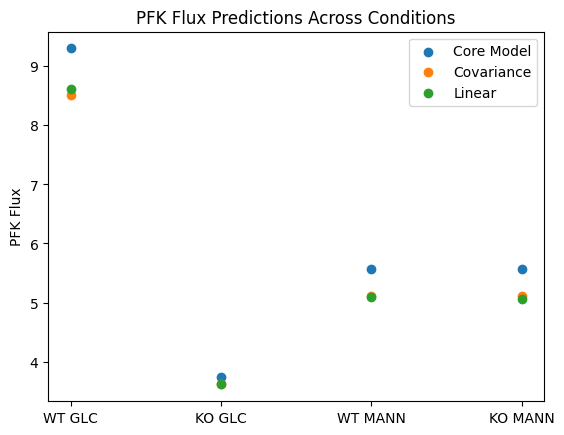

In [21]:
plt.scatter(range(4),pfk_core,label='Core Model')
plt.scatter(range(4),pfk_cov,label='Covariance')
plt.scatter(range(4),pfk_lin,label='Linear')
plt.xticks(range(4), ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN'])
plt.ylabel('PFK Flux')
plt.title('PFK Flux Predictions Across Conditions')
plt.legend()
plt.show()

## Getting errors

### Lower

In [22]:
bounds_list = [[(0,1000),(-11.4,-11.4),(0,0)],
               [(0,0),(-5.1,-5.1),(0,0)],
               [(0,1000),(0,0),(-7.9,-7.9)],
               [(0,0),(0,0),(-7.9,-7.9)]
]
qm = None   # Let WT glc determine qm and fix for the others 
pfk_core_low = []
pfk_cov_low = []
for i,bound in enumerate(bounds_list):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel,bound,qm = qm,error_type='covariance')
    pfk_core_low.append(pfk_core_run[0])
    pfk_cov_low.append(pfk_cov_run[0])

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0x6821c37a
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 593 rows and 536 columns
Presolve time: 0.01s
Presolved: 558 rows,

In [23]:
bounds_list = [[(0,1000),(-11.4,-11.4),(0,0)],
               [(0,0),(-5.1,-5.1),(0,0)],
               [(0,1000),(0,0),(-7.9,-7.9)],
               [(0,0),(0,0),(-7.9,-7.9)]
]
# qm = None   # Let WT glc determine qm and fix for the others 
gams = None   # Let WT glc determine gams and fix for the others 
pfk_lin_low = []
for i,bound in enumerate(bounds_list):  # takes 5:20 mins 
    pfk_core_run, pfk_lin_run, gams = non_regressed(tmodel,bound,gams=gams,error_type='linear',nullspace=nullspace_matrix)
    pfk_lin_low.append(pfk_lin_run[0])

Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1385 rows, 1421 columns and 9325 nonzeros
Model fingerprint: 0x69c65f3d
Model has 122 quadratic constraints
Variable types: 1300 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [3e-12, 1e+08]
  QMatrix range    [1e+00, 3e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 870 rows and 875 columns
Presolve

### Upper

In [24]:
bounds_list = [[(0,1000),(-10.0,-10.0),(0,0)],
               [(0,0),(-3.5,-3.5),(0,0)],
               [(0,1000),(0,0),(-4.9,-4.9)],
               [(0,0),(0,0),(-4.9,-4.9)]
]
qm = None   # Let WT glc determine qm and fix for the others 
pfk_core_up = []
pfk_cov_up = []
for i,bound in enumerate(bounds_list):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel,bound,qm = qm,error_type='covariance')
    pfk_core_up.append(pfk_core_run[0])
    pfk_cov_up.append(pfk_cov_run[0])

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0x90c11b3c
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 593 rows and 536 columns
Presolve time: 0.01s
Presolved: 558 rows,

In [25]:
bounds_list = [[(0,1000),(-10.0,-10.0),(0,0)],
               [(0,0),(-3.5,-3.5),(0,0)],
               [(0,1000),(0,0),(-4.9,-4.9)],
               [(0,0),(0,0),(-4.9,-4.9)]
]
# qm = None   # Let WT glc determine qm and fix for the others 
gams = None   # Let WT glc determine gams and fix for the others 
pfk_lin_up = []
for i,bound in enumerate(bounds_list):  # takes 5:20 mins 
    pfk_core_run, pfk_lin_run, gams = non_regressed(tmodel,bound,gams=gams,error_type='linear',nullspace=nullspace_matrix)
    pfk_lin_up.append(pfk_lin_run[0])

Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1385 rows, 1421 columns and 9325 nonzeros
Model fingerprint: 0x81fa83c0
Model has 122 quadratic constraints
Variable types: 1300 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [3e-12, 1e+08]
  QMatrix range    [1e+00, 3e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 870 rows and 875 columns
Presolve

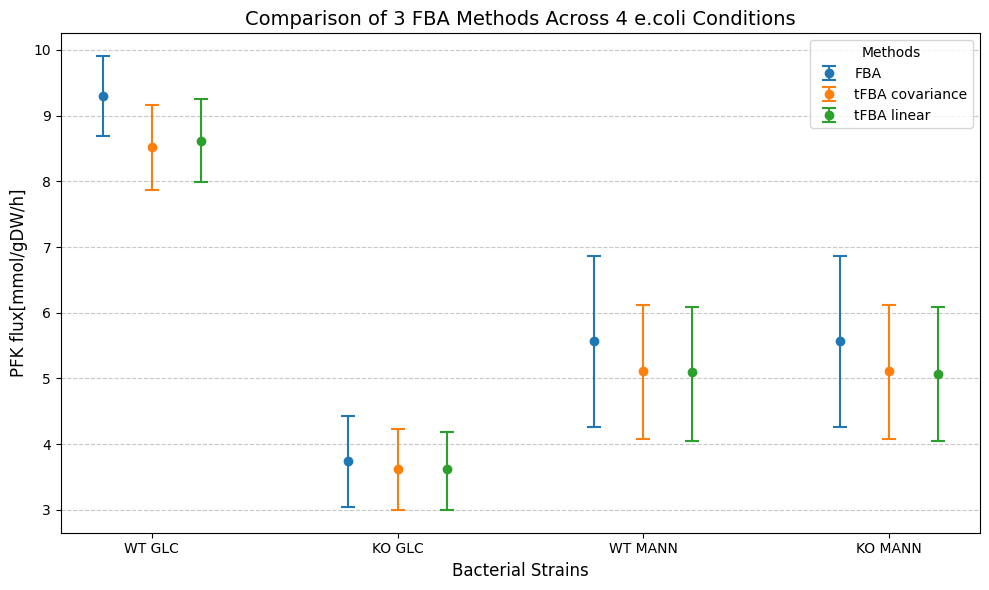

In [26]:

# 1. Define your categories
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# Setup the X-axis positions and spacing
x = np.arange(len(strains))  
width = 0.2                  
offsets = [-width, 0, width] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(10, 6))

# 3. Group your variables into a list of tuples for easy iteration
# Format: ('Label Name', mean_list, lower_list, upper_list)
methods_data = [
    ('FBA', pfk_core, pfk_core_low, pfk_core_up),
    ('tFBA covariance', pfk_cov, pfk_cov_low, pfk_cov_up),
    ('tFBA linear', pfk_lin, pfk_lin_low, pfk_lin_up)
]

# 4. Loop through the bundled data
for i, (method_name, mean, lower_bound, upper_bound) in enumerate(methods_data):
    
    # Convert lists to numpy arrays
    mean = np.array(mean)
    bound1 = np.array(upper_bound)
    bound2 = np.array(lower_bound)
    
    # NEW LOGIC: 
    # Stack the three arrays together. This creates a grid where we can look at 
    # the mean, bound1, and bound2 for a specific strain all at once.
    all_vals = np.vstack([mean, bound1, bound2])
    
    # Find the true minimum and maximum values for each strain (axis=0 means column-by-column)
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    for k in range(len(strains)):
        if true_min[k]!=bound1[k]:
            print(method_name,"not min",strains[k])
        if true_max[k]!=bound2[k]:
            print(method_name,"not max",strains[k])
    # Calculate the relative errors (now guaranteed to be 0 or positive)
    lower_error = mean - true_min
    upper_error = true_max - mean
    
    yerr = [lower_error, upper_error]
    
    # Plot points and error bars
    plt.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=method_name, color=colors[i], capsize=5, capthick=1.5, 
                 elinewidth=1.5, markersize=6)

# Formatting
plt.xticks(x, strains)
plt.xlabel('Bacterial Strains', fontsize=12)
plt.ylabel('PFK flux[mmol/gDW/h]', fontsize=12)
plt.title('Comparison of 3 FBA Methods Across 4 e.coli Conditions', fontsize=14)
plt.legend(title='Methods')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
 

In [ ]:
# import pandas as pd

# conditions = ["WT Glc", "KO Glc", "WT Man", "KO Man"]
# metrics = ["Value", "Low", "Upper"]

# indices = []
# rows = []

# for method_name, val, val_low, val_up in methods_data:
#     indices.append(method_name)
#     rows.append(list(val) + list(val_low) + list(val_up))

# # Create a 2-level column hierarchy
# # This creates combinations like ("Value", "WT Glc"), ("Value", "KO Glc")...
# multi_columns = pd.MultiIndex.from_product(
#     [metrics, conditions], 
#     names=["Metric", "Condition"]
# )

# df = pd.DataFrame(rows, index=indices, columns=multi_columns)
# df.to_csv('methods_output_multi.csv')

## range Covariance Non-Regression

In [ ]:
# # add the TFBA variables to the model
# tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
# tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = 12, error_type = 'covariance')

# # this has now created a Gurobi model object accessible via tmodel.m
# print(tmodel.m)

# # The gurobi model object can be interacted with directly via the gurobypy api. Extensive documentation can be found here: https://www.gurobi.com/documentation/10/refman/py_model.html

# #set a 15s time limit for the solver
# tmodel.m.Params.TimeLimit = 150

# # start the optimization 
# tmodel.m.optimize()

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
<gurobi.Model MIP instance minlp: 1094 constrs, 1020 vars, Parameter changes: TimeLimit=10.0, Username=(user-defined), LicenseID=2676824, NonConvex=2>
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0xd5a0681e
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or

In [ ]:
# # All the TFBA variables are now stored in the tmodel.mvars dictionary
# print(tmodel.mvars.keys())
# # these are gurobi mvar objects and can be modified (e.g. lower and upper bounds start values etc.) using the.gurobipy api

# # otherwise a solution dataframe is generated by tmodel.solution()
# sol = tmodel.solution()

# #create a list of internal and exchange reactions based on cobra boundary function 
# int_rxns = [rxn.id for rxn  in tmodel.reactions if rxn not in tmodel.boundary]
# ex_rxns = [rxn.id for rxn  in tmodel.reactions if rxn  in tmodel.boundary]

# #index the solution dataframe using these lists and sum the gibbs energy dissipation 
# print('Gdiss internal: ', sol.loc[int_rxns]['Gdiss'].sum())
# print('Gdiss exchange: ', sol.loc[ex_rxns]['Gdiss'].sum())
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(sol)


dict_keys(['b', 'v', 'drGp', 'drGn', 'ln_conc', 'drG', 'drG_error', 'drG_conc', 'qm', 'mnorm', 'Gdiss', 'g_2'])
Gdiss internal:  -3637.802758836463
Gdiss exchange:  3637.798723083808


,v,drG,Gdiss,drG0_prime,drG_error,drG_conc,b,condition
reaction,,,,,,,,
PFK,7.872848,-4.157826,-32.733929,-1.976517e+01,0.121388,15.485956,1.000000e+00,0
PFL,5.542170,-7.810184,-43.285364,-1.976903e+01,1.864662,10.094183,1.000000e+00,0
PGI,5.153066,-6.040350,-31.126323,2.630066e+00,0.060534,-8.730950,1.000000e+00,0
PGK,-16.954266,3.540634,-60.028857,1.952409e+01,-0.048414,-15.935038,0.000000e+00,0
PGL,4.733740,-16.720261,-79.149362,-2.679429e+01,-0.312303,10.386328,1.000000e+00,0
ACALD,0.000000,19.333761,0.000000,-2.204629e+01,0.286814,41.093235,0.000000e+00,0
AKGt2r,0.000000,22.132101,0.000000,1.099270e+01,-0.000000,11.139404,0.000000e+00,0
PGM,-16.128227,2.861651,-46.153357,-4.485410e+00,-0.055583,7.402644,0.000000e+00,0
PIt2r,2.031250,-0.501059,-1.017776,1.125718e+01,-0.000000,-11.758239,1.000000e+00,0


In [ ]:
# qm = tmodel.mvars['qm'].x#get the qm values from the initial solution
# # First we fix the drG_errors to the values from our initial optimization 
# # This is optional but will:
# # i: help the solver converge faster
# # ii: ensure we have a consistent set of drG0prime values for each glucose uptake condition (this is analgous to running the 
# # regressions on literature data and using this to fix the drGerror values)) 

# # the qm vector defines the errors in the covariance matrix 
 
# #fix the values in the model 
# tmodel.mvars['qm'].lb = qm 
# tmodel.mvars['qm'].ub = qm
# tmodel.m.update() #update the model with the new bounds

# Regression

## Cleaning data 

(only conditions with important reactions existing in the model, only existing metabolites)

In [ ]:
# loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'

# # Load the provided data
# df = pd.read_csv(loc + 'allPhysioData_formatted_forGSM_20230831.csv')

# # 1. Drop conditions that require hard-to-add pathways or full GEM
# conditions_to_drop = ['WT-Gal_I', 'WT-GlyCAA_II']
# df_filtered = df[~df['cond'].isin(conditions_to_drop)].copy()

# # 2. Drop reactions not in the core model
# rxns_to_drop = ['EX_oro']
# df_filtered = df_filtered[~df_filtered['rxn'].isin(rxns_to_drop)].copy()

# # 3. Rename remaining reactions to match your model exactly
# rename_dict = {
#     'biomass_EX': 'BIOMASS_Ecoli_core_w_GAM',
#     'EX_ac': 'EX_ac_e',
#     'EX_co2': 'EX_co2_e',
#     'EX_o2': 'EX_o2_e',
#     'EX_fru': 'EX_fru_e',
#     'EX_succ': 'EX_succ_e',
#     'EX_fum': 'EX_fum_e',
#     'EX_glc__D': 'EX_glc__D_e',
#     'EX_glyc': 'EX_glyc_e',
#     'EX_man': 'EX_man__D_e',
#     'EX_for': 'EX_for_e',
#     'EX_pyr': 'EX_pyr_e',
#     'EX_lac__D': 'EX_lac__D_e',
#     'EX_mal__L': 'EX_mal__L_e'
# }
# df_filtered['rxn'] = df_filtered['rxn'].replace(rename_dict)
# # This forces the dataframe to re-number itself sequentially and drops the old broken numbering
# df_filtered.reset_index(drop=True, inplace=True)
# df_indexed = df_filtered.set_index(['cond','rxn'])
# # Save the new DataFrame
# # df_filtered.to_csv(loc+'cleaned_physio_data.csv', index=False)

In [ ]:
# # Load the datasets
# loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'
# flux_data = pd.read_csv(loc+'cleaned_physio_data.csv')
# metab_data = pd.read_csv(loc+'metabolomics-Kochanowski_20230925.csv')

# # Define the metabolites in your model 
# model_metabolites = [met.id for met in tmodel.metabolites]
# # Extract the base names (ignoring compartment suffixes like _c or _e to match the data)
# base_model_mets = set(["_".join((m).split('_')[:-1]) for m in model_metabolites])

# # 3. Filter 1: Keep only conditions that have corresponding flux data
# valid_conditions = flux_data['cond'].unique()
# cleaned_metab = metab_data[metab_data['cond'].isin(valid_conditions)].copy()

# # 4. Map formatting differences (Kochanowski -> BiGG format)
# rename_map = {
#     'ru5p-D': 'ru5p__D',
#     'xu5p-D': 'xu5p__D',
#     'acon-C': 'acon_C',
#     'mal-L': 'mal__L',
#     'glu-L': 'glu__L',
#     'gln-L': 'gln__L',
#     'lac-D': 'lac__D',
#     'glc-D': 'glc__D',
#     'man-D': 'man__D'
# }
# cleaned_metab['met'] = cleaned_metab['met'].replace(rename_map)

# # 5. Filter 2: Drop metabolites that are not in the model
# cleaned_metab = cleaned_metab[cleaned_metab['met'].isin(base_model_mets)]

# # 6. Save the new dataset
# # cleaned_metab.to_csv(loc+'cleaned_metabolomics_data.csv', index=False)

# print("Original metabolomics conditions:", metab_data['cond'].unique())
# print("Cleaned metabolomics conditions:", cleaned_metab['cond'].unique())
# print(f"Total rows saved: {len(cleaned_metab)}")

Original metabolomics conditions: ['WT-Gal_I' 'WT-Ace_I' 'WT-Mann_I' 'WT-Pyr_I' 'WT-Glyc_I' 'WT-Fruc_I'
 'WT-Succ_I' 'WT-Glc_I' 'WT-GlcCAA_I']
Cleaned metabolomics conditions: ['WT-Ace_I' 'WT-Mann_I' 'WT-Pyr_I' 'WT-Glyc_I' 'WT-Fruc_I' 'WT-Succ_I'
 'WT-Glc_I']
Total rows saved: 138


In [ ]:
# tmodel.reactions.ATPM.bounds = (0,1000)
tmodel.reactions.EX_ac_e.bounds = (-1000,1000)
print(tmodel.reactions.EX_glc__D_e.bounds)
#remove the bound on the glucose uptake flux (previously set to -10))
tmodel.reactions.EX_glc__D_e.lower_bound = -1000

(-10.0, 1000.0)


## Double regression

In [17]:
loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'
flux_data = pd.read_csv(loc+'cleaned_physio_data.csv')
valid_conditions = flux_data['cond'].unique()
print(valid_conditions)

['WT-Ace_I' 'WT-Fruc_I' 'WT-Fum_I' 'WT-Glc_I' 'WT-Glyc_I' 'WT-Mann_I'
 'WT-Pyr_I' 'WT-Succ_I' 'dptsG-Glc_I']


### Get regression predicitons for different condition subsets

Enabling fitting multiple conditions by selectively limiting uptakes through mvars, not model bounds. Goal is to get qm values for three subsets of possible regression conditions. Rerun the following cells with different subsets and save qm to datafiles folder under regressed_qm{N}conds.npy. append to methods_output_mullti the predictions of a model with original bounds but those qm.

In [18]:

# conds = ['WT-Glc_I','WT-Mann_I','dptsG-Glc_I','WT-Ace_I','WT-Fruc_I','WT-Fum_I','WT-Glyc_I']

# conds = ['WT-Glc_I','WT-Mann_I','dptsG-Glc_I']
conds = ['WT-Ace_I','WT-Fruc_I','WT-Fum_I','WT-Glyc_I']

loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'
df_filtered = pd.read_csv(loc+'cleaned_physio_data.csv')
df_indexed = df_filtered.set_index(['cond','rxn'])
tmodel.m = None 

# 1. Define lists of things that need condition-specific clamping
all_carbon_sources = [
    'EX_glc__D_e', 'EX_ac_e', 'EX_fru_e', 'EX_succ_e', 
    'EX_fum_e', 'EX_glyc_e', 'EX_man__D_e', 'EX_pyr_e'
]

all_acid_exchanges = [
    'EX_mal__L_e', 'EX_fum_e', 'EX_succ_e', 
    'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e'
]

# Combine them for the clamping loop to be clean
all_elective_exchanges = list(set(all_carbon_sources + all_acid_exchanges))

acid_transporter_map = {
    'EX_mal__L_e': 'MALt2_2',
    'EX_fum_e': 'FUMt2_2',
    'EX_succ_e': 'SUCCt2_2', 
    'EX_lac__D_e': 'D_LACt2',
    'EX_pyr_e': 'PYRt2',
    'EX_ac_e': 'ACt2r'
}

# =====================================================================
# THE MISSING GENERAL OPENING: Open base bounds before TFBA generation
# =====================================================================

# Open all elective exchanges globally in the base model
for rxn_id in all_elective_exchanges:
    if rxn_id in tmodel.reactions:
        tmodel.reactions.get_by_id(rxn_id).bounds = (-1000.0, 1000.0)

# Open the internal transporters ONLY for conditions where the acid is measured
for cond_name in conds:
    active_rxns = df_filtered[df_filtered['cond'] == cond_name]['rxn'].tolist()
    for ex_rxn, transport_rxn in acid_transporter_map.items():
        if ex_rxn in active_rxns and transport_rxn in tmodel.reactions:
            tmodel.reactions.get_by_id(transport_rxn).bounds = (-1000.0, 1000.0)

# Catch the Core model quirk for Succinate
if 'EX_succ_e' in df_filtered['rxn'].values and 'SUCCt3' in tmodel.reactions:
    tmodel.reactions.get_by_id('SUCCt3').bounds = (-1000.0, 1000.0)

# =====================================================================

# 2. Generate the TFBA variables using the newly opened bounds
tmodel.add_TFBA_variables(conds = conds, gdiss_constraint = False, error_type='covariance') 

v = tmodel.mvars['v'] 
reaction_ids = [rxn.id for rxn in tmodel.reactions]

# 3. Clamp inactive sources AND unmeasured acids to 0 directly in Gurobi
for cond_index, cond_name in enumerate(conds):
    active_rxns = df_filtered[df_filtered['cond'] == cond_name]['rxn'].tolist()
    
    for ex_rxn in all_elective_exchanges:
        if ex_rxn in tmodel.reactions and ex_rxn not in active_rxns:
            # If it's not the active carbon source, AND it wasn't measured 
            # as a secreted byproduct, we lock the exchange to 0.
            rxn_idx = reaction_ids.index(ex_rxn)
            v[cond_index, rxn_idx].lb = 0
            v[cond_index, rxn_idx].ub = 1000

# Apply the clamping changes to the Gurobi backend
tmodel.m.update()

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10


In [20]:
loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'
cleaned_metab = pd.read_csv(loc + 'cleaned_metabolomics_data.csv')

# cleaned_metab['sd'] = cleaned_metab['sd'] * 3.0

# cleaned_metab.loc['sd'] = cleaned_metab.apply(
#     lambda row: max(row['sd'], row['mean'] * 0.30, 0.05), axis=1)
# # TRY REMOVING LARGE SOURCE OF REGRESSION ERROR FROM CONCENTRATIONS
# cleaned_metab = cleaned_metab[cleaned_metab['met'] != 'dhap']
# cleaned_metab = cleaned_metab[cleaned_metab['met'] != 'pep']
# unique_mets = cleaned_metab[cleaned_metab['met'] != "13dpg"]['met'].unique()
unique_mets = cleaned_metab['met'].unique()
# 3. Create a master index of ALL conditions (from your conds list) x ALL metabolites
idx = pd.MultiIndex.from_product([conds, unique_mets], names=['cond', 'met'])

# 4. Set the index and apply the master index (filling missing conditions with NaN)
cleaned_metab_indexed = cleaned_metab.set_index(['cond', 'met']).reindex(idx)

# Now, volume_data_df should also cover all conditions
volume_dict = {'c': [1.0] * len(conds)}
volume_data_df = pd.DataFrame(volume_dict, index=conds)

In [21]:
#add regression constraint to this TFBA model 
tmodel.regression(conds,
                  flux_data=df_indexed, #provide the experimental data as a dataframe indexed by condition and reaction
                  metabolite_data=cleaned_metab_indexed, 
                  volume_data=volume_data_df,
                  conc_fit=True,
                  error_type = 'covariance', 
                  flux_fit=True, #fit to the flux data 
                  drG_fit=True,  # optional, minimise the drG errors to make the drG0prime close to the mean values 
                  resnorm=2,
                  conc_units='mM') #the norm to use for the regression 1: L1 norm (sum of absolute differences), 2: L2 norm (sum of squared differences)

In [22]:
# 1. Shift focus entirely to finding feasible solutions quickly (1) instead of proving optimality (2 or 3)
tmodel.m.Params.MIPFocus = 1

# 2. Tell the solver to spend 50% of its time doing random heuristic jumping (Default is only 5% or 0.05)
tmodel.m.Params.Heuristics = 0.5 

tmodel.m.update()

Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.5


In [26]:
tmodel.m.Params.TimeLimit = 600
tmodel.m.optimize()

Set parameter TimeLimit to value 600
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.5.0 25F80)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  600
Heuristics  0.5
MIPFocus  1
NonConvex  2

Academic license 2836280 - for non-commercial use only - registered to e.___@student.rug.nl
Optimize a model with 4089 rows, 3729 columns and 16990 nonzeros
Model fingerprint: 0x71819108
Model has 59 quadratic objective terms
Model has 79 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Model has 80 function constraints treated as nonlinear
  80 EXP
Variable types: 3245 continuous, 484 integer (484 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [7e-02, 2e+11]
  QLMatrix range   [1e+00, 2e+07]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [1e-09, 1e+08]
  RHS range        [1e-14, 1e+08]
  QRH

In [ ]:
# successful_qm = tmodel.mvars['qm'].X
# np.save(loc + 'regressed_qm_4cond_noGM.npy', successful_qm)

In [104]:
# Run this immediately after tmodel.regression(...) finishes

print("================ NEW BOTTLENECK DIAGNOSTIC ================")
for cond_idx, cond_name in enumerate(conds):
    # Extract the exact residual variables Gurobi calculated for this condition
    gurobi_residuals = tmodel.mvars['resconc'][cond_idx].X
    
    # Get the list of measured metabolites the solver actually used
    measured_mets = list(cleaned_metab_indexed.loc[cond_name].dropna().index)
    
    print(f"\n--- {cond_name} ---")
    found_bottleneck = False
    
    for i, met_id in enumerate(measured_mets):
        raw_val = gurobi_residuals[i]
        
        # Print anything taking a noticeable penalty
        if raw_val > 10: 
            print(f"{met_id:<15} | Penalty: {raw_val:.2f}")
            found_bottleneck = True
            
    if not found_bottleneck:
        print("No major penalties in this condition.")

print("===========================================================")

================ NEW BOTTLENECK DIAGNOSTIC ================

--- WT-Glc_I ---
13dpg           | Penalty: 9049.26

--- WT-Mann_I ---
13dpg           | Penalty: 2080.28

--- dptsG-Glc_I ---
No major penalties in this condition.


In [45]:
successful_qm = tmodel.mvars['qm'].X


In [23]:
import pandas as pd

# 1. DEFINE YOUR THIRD QM VARIABLE HERE
# Replace 'qm_third' with your actual variable name if it's named something else
qm_third =  np.load(loc + 'regressed_qm_3conds.npy')


# 2. RUN SIMULATION FOR BASE BOUNDS
bounds_list_base = [
    [(0,1000),(-10.7,-10.7),(0,0)],
    [(0,0),(-4.3,-4.3),(0,0)],
    [(0,1000),(0,0),(-6.4,-6.4)],
    [(0,0),(0,0),(-6.4,-6.4)]
]
pfk_core_third = []
pfk_cov_third = []
qm = None   

for i, bound in enumerate(bounds_list_base):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel, bound, qm=qm_third, error_type='covariance')
    pfk_core_third.append(pfk_core_run[0])
    pfk_cov_third.append(pfk_cov_run[0])


# 3. RUN SIMULATION FOR UPPER BOUNDS
bounds_list_up = [
    [(0,1000),(-10.0,-10.0),(0,0)],
    [(0,0),(-3.5,-3.5),(0,0)],
    [(0,1000),(0,0),(-4.9,-4.9)],
    [(0,0),(0,0),(-4.9,-4.9)]
]
pfk_core_up_third = []
pfk_cov_up_third = []
qm = None   

for i, bound in enumerate(bounds_list_up):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel, bound, qm=qm_third, error_type='covariance')
    pfk_core_up_third.append(pfk_core_run[0])
    pfk_cov_up_third.append(pfk_cov_run[0])


# 4. RUN SIMULATION FOR LOWER BOUNDS
bounds_list_low = [
    [(0,1000),(-11.4,-11.4),(0,0)],
    [(0,0),(-5.1,-5.1),(0,0)],
    [(0,1000),(0,0),(-7.9,-7.9)],
    [(0,0),(0,0),(-7.9,-7.9)]
]
pfk_core_low_third = []
pfk_cov_low_third = []
qm = None   

for i, bound in enumerate(bounds_list_low):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel, bound, qm=qm_third, error_type='covariance')
    pfk_core_low_third.append(pfk_core_run[0])
    pfk_cov_low_third.append(pfk_cov_run[0])


# 5. LOAD, APPEND, AND SAVE TO A COPIED FILE
# Points to your existing file that contains the previous data rows
input_file_path = 'methods_output_multi_14_05_v4.csv'  
df = pd.read_csv(input_file_path, index_col=0, header=[0, 1])

# Combine the 3rd condition lists into a single row of 12 values (Base + Low + Up)
new_row = pfk_cov_third + pfk_cov_low_third + pfk_cov_up_third

# Append the third dataset with its own distinct row label
row_label = 'tFBA regressed (3 conditions G/M)'  
df.loc[row_label] = new_row

# Save to a brand new filename so the original file remains untouched
output_file_path = 'methods_output_multi_14_05_v5.csv'
df.to_csv(output_file_path)

print(f"Success! Third condition appended. Saved to safe copy: '{output_file_path}'")

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.5.0 25F80)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Academic license 2836280 - for non-commercial use only - registered to e.___@student.rug.nl
Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0x3ffef063
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-07, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical i

In [28]:
loc = '/Users/eduardmrug/Documents/Honours research/main_program/examples/ecoli/textbook/datafiles/'
qm3 = np.load(loc + 'regressed_qm_3conds.npy')
qm7 = np.load(loc + 'regressed_qm_7conds.npy')

In [ ]:
# # Load your previous 3-method data
# # We use header=[0, 1] because your CSV has 'Metric' on row 1 and 'Condition' on row 2
# file_path = 'methods_output_multi_14_05.csv'
# df = pd.read_csv(file_path, index_col=0, header=[0, 1])

# # Combine your 7-condition lists into a single row of 12 values
# # (Make sure pfk_cov7, pfk_cov_low7, and pfk_cov_up7 are loaded in memory from your previous cells)
# new_row = pfk_cov7 + pfk_cov_low7 + pfk_cov_up7

# # Append the new method to the dataframe
# df.loc['tFBA regressed (7 cond)'] = new_row

# # Save the complete file
# new_file_path = 'methods_output_multi_14_05_updated.csv'
# df.to_csv(new_file_path)
# print(f"Updated data saved successfully to '{new_file_path}'!")

Updated data saved successfully to 'methods_output_multi_14_05_updated.csv'!


### Plot comparison of regression subset predictions.

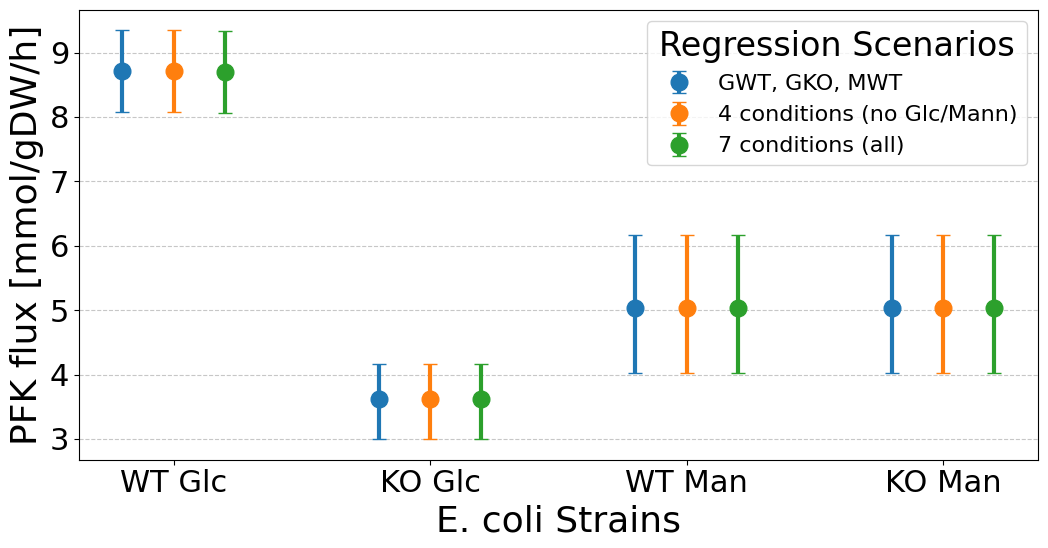

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the updated data directly from your CSV
# Replace 'methods_output_multi_14_05_v3.csv' with your actual file path
file_path = 'methods_output_multi_14_05_v5.csv'
df = pd.read_csv(file_path, index_col=0, header=[0, 1])

# 2. Define the exact row names from your CSV and what you want them called in the legend
methods_to_plot = [
    ('tFBA regressed (3 conditions G/M)', 'GWT, GKO, MWT'),
    ('tFBA regressed (4 conditions no G/M)', '4 conditions (no Glc/Mann)'),
    ('tFBA regressed (7 conditions)', '7 conditions (all)'),
]

# 3. Setup the X-axis categories based on the CSV's inner column labels
strains = ['WT Glc', 'KO Glc', 'WT Man', 'KO Man']
x = np.arange(len(strains))  

# 4. Configure spacing for THREE distinct methods per group
width = 0.2                  
offsets = [-width, 0, width]     # Center bar stays at 0, others shift left/right
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

plt.figure(figsize=(11, 6))

# 5. Loop through and extract data directly from the Dataframe
for i, (row_name, display_name) in enumerate(methods_to_plot):
    
    # Slicing the MultiIndex: df.loc[row, outer_column_level]
    mean = df.loc[row_name, 'Value'].to_numpy()
    bound1 = df.loc[row_name, 'Low'].to_numpy()
    bound2 = df.loc[row_name, 'Upper'].to_numpy()
    
    # Find absolute max/min limits to handle the inverted values seamlessly
    all_vals = np.vstack([mean, bound1, bound2])
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    # Calculate the asymmetrical relative error intervals
    lower_error = mean - true_min
    upper_error = true_max - mean
    yerr = [lower_error, upper_error]
    
    # Plot points and error bars side-by-side using the calculated offsets
    plt.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=display_name, color=colors[i],capsize=5)   #, capthick=1.5, elinewidth=1.5, markersize=6

# 6. Plot Styling and Formatting
plt.xticks(x, strains)
plt.xlabel('E. coli Strains')
plt.ylabel('PFK flux [mmol/gDW/h]')
# plt.title('Prediction Comparison: tFBA Regressed on 3, 4, vs 7 Conditions', fontsize=14)
plt.legend(title='Regression Scenarios', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot directly to your directory for your submission
plt.savefig('/Users/eduardmrug/Downloads/EcoliPoster/regression_comparison.pdf', format="pdf", bbox_inches="tight")
plt.show()

In [18]:
new_file_path = 'methods_output_multi_14_05_updated.csv'
df = pd.read_csv(new_file_path, index_col=0, header=[0, 1])

### Compare constraint methods

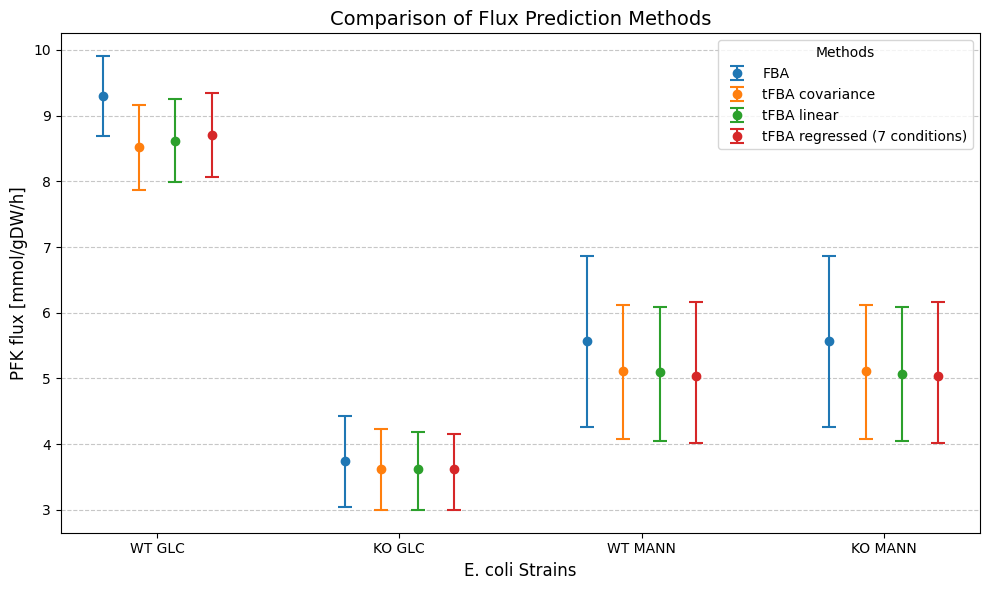

In [32]:
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']
methods = df.index.tolist() # Automatically grabs the 4 method names from the CSV

# Setup the X-axis positions and spacing for FOUR methods
x = np.arange(len(strains))  
width = 0.15                  
# 4 methods means 4 offsets centered around the tick mark (-1.5, -0.5, 0.5, 1.5)
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

plt.figure(figsize=(10, 6))

# Loop directly through the dataframe index
for i, method_name in enumerate(methods):
    
    # Extract the arrays from the DataFrame based on the top-level Metric headers
    mean = df.loc[method_name, 'Value'].values
    bound1 = df.loc[method_name, 'Upper'].values
    bound2 = df.loc[method_name, 'Low'].values
    
    # Stack and find true min/max to prevent negative error bars
    all_vals = np.vstack([mean, bound1, bound2])
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    # Calculate positive relative errors
    lower_error = mean - true_min
    upper_error = true_max - mean
    
    yerr = [lower_error, upper_error]
    
    # Plot points and error bars
    plt.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=method_name, color=colors[i], capsize=5, capthick=1.5, 
                 elinewidth=1.5, markersize=6)

# Formatting
plt.xticks(x, strains)
plt.xlabel('E. coli Strains', fontsize=12)
plt.ylabel('PFK flux [mmol/gDW/h]', fontsize=12)
plt.title('Comparison of Flux Prediction Methods', fontsize=14)
plt.legend(title='Methods')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

## Main plot of experiment vs prediction

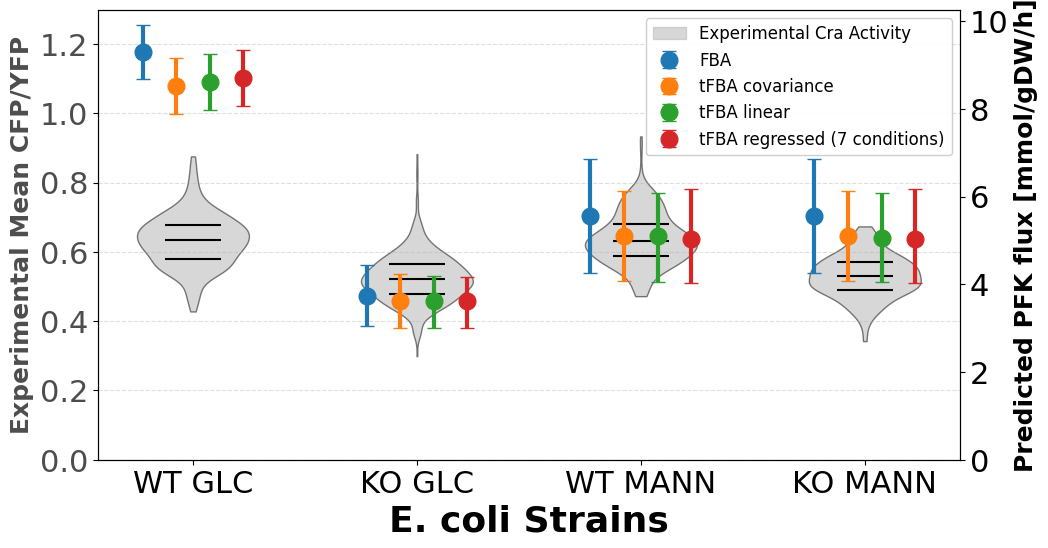

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =====================================================================
# 0. LOAD PREDICTED FLUX DATA (From your updated CSV)
# =====================================================================
# Load the dataframe with the multi-level header (Metric, Condition)
file_path = 'methods_output_multi_14_05_updated.csv'
df = pd.read_csv(file_path, index_col=0, header=[0, 1])

# =====================================================================
# 1. LOAD EXPERIMENTAL DATA (VIOLINS)
# =====================================================================
experiments_path = "/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/"
experiments = ['20250729_GWT305', '20250729_GKO305', '20250729_MWT305/', '20250729_MKO305/']
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# Toggle between 'mean' or 'max'
data_type = 'mean' 

plot_data = []
for exp in experiments:
    path_base = os.path.join(experiments_path, exp)
    path_out = os.path.join(path_base, "Analysis")
    df_total = pd.read_pickle(os.path.join(path_out, "dataframe_fluorescence_bandpass-values.pkl"))
    
    if data_type == 'max':
        plot_data.append(df_total[df_total["ratio_max"] <= 1]['ratio_max'])
    else:
        plot_data.append(df_total[df_total["ratio_mean"] <= 1]['ratio_mean'])

# =====================================================================
# 2. SETUP FIGURE & DUAL AXES
# =====================================================================
fig, ax1 = plt.subplots(figsize=(11, 6))
x = np.arange(len(strains))

# =====================================================================
# 3. PLOT PROTEOMICS (LEFT Y-AXIS: VIOLINS)
# =====================================================================
# We use positions=x so the violins align perfectly with the flux dots
parts = ax1.violinplot(plot_data, positions=x, showmeans=False, showmedians=False, showextrema=False, 
                       quantiles=[[0.25, 0.5, 0.75] for _ in experiments])

# Color the violins a neutral gray so they act as a clean background
violin_color = '#b0b0b0'
for pc in parts['bodies']:
    pc.set_facecolor(violin_color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.5) # Semi-transparent so we can see the grid and dots

# Color the internal quantile lines black for visibility
if 'cquantiles' in parts:
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1.5)

ax1.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP', color='#4d4d4d', fontsize=18, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4d4d4d')
ax1.set_xticks(x)
ax1.set_xticklabels(strains)
ax1.set_xlabel('E. coli Strains',  fontweight='bold')

# =====================================================================
# 4. PLOT PREDICTIONS (RIGHT Y-AXIS: FLUX ERROR BARS)
# =====================================================================
ax2 = ax1.twinx() # Create the second Y-axis sharing the same X-axis

methods = df.index.tolist() 

width = 0.15                  
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

for i, method_name in enumerate(methods):
    mean = df.loc[method_name, 'Value'].values
    bound1 = df.loc[method_name, 'Upper'].values
    bound2 = df.loc[method_name, 'Low'].values
    
    all_vals = np.vstack([mean, bound1, bound2])
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    lower_error = mean - true_min
    upper_error = true_max - mean
    yerr = [lower_error, upper_error]
    
    # zorder=3 ensures the flux dots are drawn ON TOP of the violins
    ax2.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=method_name, color=colors[i], capsize=5, zorder=3)   #capthick=1.5, elinewidth=1.5, markersize=7

ax2.set_ylabel('Predicted PFK flux [mmol/gDW/h]', color='black',fontsize=18,  fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# =====================================================================
# 5. AXIS SYNCHRONIZATION MATH (Anchored to WT MANN)
# =====================================================================
# Force the left axis to start exactly at 0 so proportional math works
ax1.set_ylim(bottom=0)

# 1. WT MANN is index 2 in our lists. Find the numerical mean of its experimental data.
experimental_anchor = np.mean(plot_data[2])

# 2. Pick the flux method you want to use as the visual anchor. 
anchor_method = 'tFBA regressed (7 conditions)' 
# [2] grabs the WT MANN value from the array
predicted_anchor = df.loc[anchor_method, 'Value'].values[2] 

# 3. Get the maximum height of the left axis after plotting
ax1_ymax = ax1.get_ylim()[1]

# 4. Calculate the required right axis maximum. 
ax2_ymax = predicted_anchor * (ax1_ymax / experimental_anchor)

# =====================================================================
# 5. AXIS SYNCHRONIZATION MATH (Anchored to WT MANN, Auto-scaling fixed)
# =====================================================================
# Force both axes to start exactly at 0
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# 1. Grab the anchors (WT MANN is index 2)
experimental_anchor = np.mean(plot_data[2])
anchor_method = 'tFBA regressed (7 conditions)' 
predicted_anchor = df.loc[anchor_method, 'Value'].values[2] 

# 2. Calculate the strict synchronization ratio
# (How many experimental intensity units equal 1 flux unit?)
sync_ratio = experimental_anchor / predicted_anchor

# 3. Find out how tall Matplotlib naturally wants to draw both datasets
current_ax1_max = ax1.get_ylim()[1]
current_ax2_max = ax2.get_ylim()[1]

# 4. Convert the Flux maximum into Experimental units using our ratio
converted_ax2_max = current_ax2_max * sync_ratio

# 5. The new Left Axis maximum must be tall enough to fit whichever is highest
final_ax1_ymax = max(current_ax1_max, converted_ax2_max)

# 6. Apply the synchronized, expanded limits to BOTH axes
ax1.set_ylim(0, final_ax1_ymax)
ax2.set_ylim(0, final_ax1_ymax / sync_ratio)

# =====================================================================
# 6. FORMATTING & LEGEND ALIGNMENT
# =====================================================================
# plt.title('In vivo Cra Activity vs. In silico Predicted PFK Flux', fontsize=14)

# Create a custom proxy artist to add the Violin Plot to the main legend
violin_patch = mpatches.Patch(color=violin_color, alpha=0.5, label='Experimental Cra Activity')
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into one clean legend box
ax2.legend([violin_patch] + lines_2, ['Experimental Cra Activity'] + labels_2, loc='upper right', framealpha=0.95, fontsize=12)

# Add a light grid behind everything
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/Users/eduardmrug/Downloads/EcoliPoster/main_comparison.pdf', format="pdf", bbox_inches="tight")
plt.show()

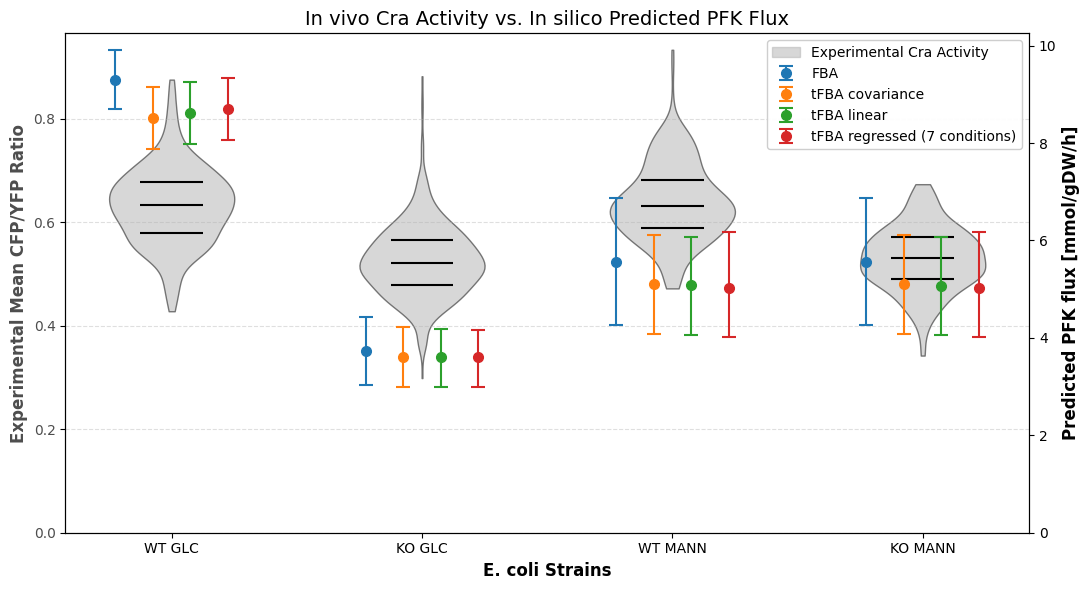

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =====================================================================
# 1. LOAD EXPERIMENTAL DATA (VIOLINS)
# =====================================================================
experiments_path = "/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/"
experiments = ['20250729_GWT305', '20250729_GKO305', '20250729_MWT305/', '20250729_MKO305/']
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# Toggle between 'mean' or 'max'
data_type = 'mean' 

plot_data = []
for exp in experiments:
    path_base = os.path.join(experiments_path, exp)
    path_out = os.path.join(path_base, "Analysis")
    df_total = pd.read_pickle(os.path.join(path_out, "dataframe_fluorescence_bandpass-values.pkl"))
    
    if data_type == 'max':
        plot_data.append(df_total[df_total["ratio_max"] <= 1]['ratio_max'])
    else:
        plot_data.append(df_total[df_total["ratio_mean"] <= 1]['ratio_mean'])

# =====================================================================
# 2. SETUP FIGURE & DUAL AXES
# =====================================================================
fig, ax1 = plt.subplots(figsize=(11, 6))
x = np.arange(len(strains))

# =====================================================================
# 3. PLOT PROTEOMICS (LEFT Y-AXIS: VIOLINS)
# =====================================================================
# We use positions=x so the violins align perfectly with the flux dots
parts = ax1.violinplot(plot_data, positions=x, showmeans=False, showmedians=False, showextrema=False, 
                       quantiles=[[0.25, 0.5, 0.75] for _ in experiments])

# Color the violins a neutral gray so they act as a clean background
violin_color = '#b0b0b0'
for pc in parts['bodies']:
    pc.set_facecolor(violin_color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.5) # Semi-transparent so we can see the grid and dots

# Color the internal quantile lines black for visibility
if 'cquantiles' in parts:
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1.5)

ax1.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP Ratio', color='#4d4d4d', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4d4d4d')
ax1.set_xticks(x)
ax1.set_xticklabels(strains)
ax1.set_xlabel('E. coli Strains', fontsize=12, fontweight='bold')

# =====================================================================
# 4. PLOT PREDICTIONS (RIGHT Y-AXIS: FLUX ERROR BARS)
# =====================================================================
ax2 = ax1.twinx() # Create the second Y-axis sharing the same X-axis

# Assuming 'df' is loaded in your environment from the updated CSV
methods = df.index.tolist() 

width = 0.15                  
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

for i, method_name in enumerate(methods):
    mean = df.loc[method_name, 'Value'].values
    bound1 = df.loc[method_name, 'Upper'].values
    bound2 = df.loc[method_name, 'Low'].values
    
    all_vals = np.vstack([mean, bound1, bound2])
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    lower_error = mean - true_min
    upper_error = true_max - mean
    yerr = [lower_error, upper_error]
    
    # zorder=3 ensures the flux dots are drawn ON TOP of the violins
    ax2.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=method_name, color=colors[i], capsize=5, capthick=1.5, 
                 elinewidth=1.5, markersize=7, zorder=3)

ax2.set_ylabel('Predicted PFK flux [mmol/gDW/h]', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# =====================================================================
# 5. FORMATTING & LEGEND ALIGNMENT
# =====================================================================
plt.title('In vivo Cra Activity vs. In silico Predicted PFK Flux', fontsize=14)

# Create a custom proxy artist to add the Violin Plot to the main legend
violin_patch = mpatches.Patch(color=violin_color, alpha=0.5, label='Experimental Cra Activity')
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Combine them into one clean legend box
ax2.legend([violin_patch] + lines_2, ['Experimental Cra Activity'] + labels_2, loc='upper right', framealpha=0.95)

# Add a light grid behind everything
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Force both Y-axes to start at 0 so the proportional scaling isn't visually deceptive
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

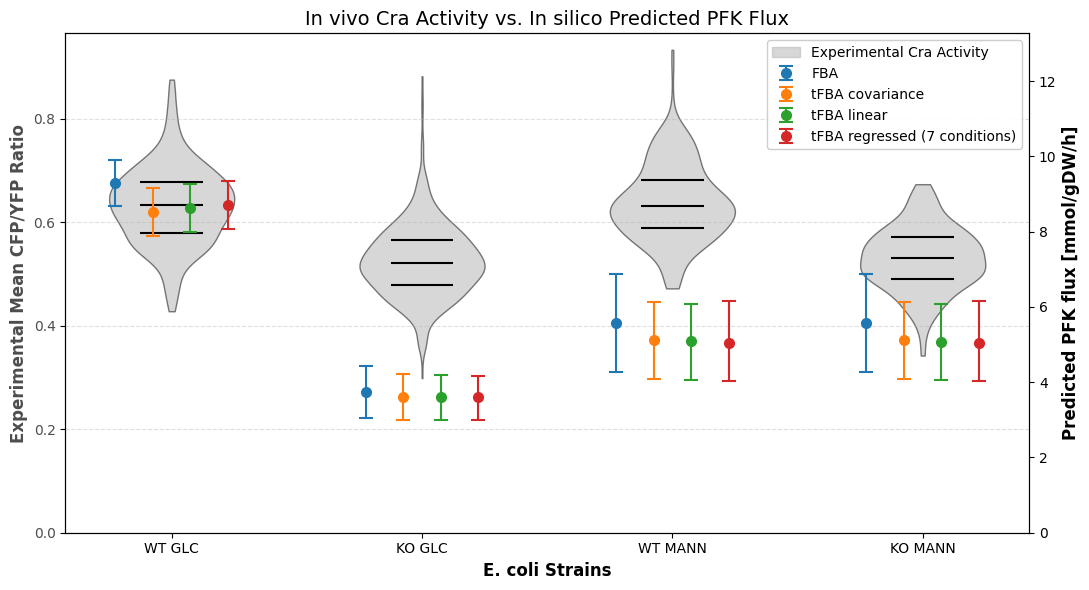

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =====================================================================
# 1. LOAD EXPERIMENTAL DATA (VIOLINS)
# =====================================================================
experiments_path = "/Users/eduardmrug/Documents/Honours research/Labwork/Experiments/"
experiments = ['20250729_GWT305', '20250729_GKO305', '20250729_MWT305/', '20250729_MKO305/']
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

data_type = 'mean' 

plot_data = []
for exp in experiments:
    path_base = os.path.join(experiments_path, exp)
    path_out = os.path.join(path_base, "Analysis")
    df_total = pd.read_pickle(os.path.join(path_out, "dataframe_fluorescence_bandpass-values.pkl"))
    
    if data_type == 'max':
        plot_data.append(df_total[df_total["ratio_max"] <= 1]['ratio_max'])
    else:
        plot_data.append(df_total[df_total["ratio_mean"] <= 1]['ratio_mean'])

# =====================================================================
# 2. SETUP FIGURE & DUAL AXES
# =====================================================================
fig, ax1 = plt.subplots(figsize=(11, 6))
x = np.arange(len(strains))

# =====================================================================
# 3. PLOT PROTEOMICS (LEFT Y-AXIS: VIOLINS)
# =====================================================================
parts = ax1.violinplot(plot_data, positions=x, showmeans=False, showmedians=False, showextrema=False, 
                       quantiles=[[0.25, 0.5, 0.75] for _ in experiments])

violin_color = '#b0b0b0'
for pc in parts['bodies']:
    pc.set_facecolor(violin_color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

if 'cquantiles' in parts:
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1.5)

ax1.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP Ratio', color='#4d4d4d', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4d4d4d')
ax1.set_xticks(x)
ax1.set_xticklabels(strains)
ax1.set_xlabel('E. coli Strains', fontsize=12, fontweight='bold')

# =====================================================================
# 4. PLOT PREDICTIONS (RIGHT Y-AXIS: FLUX ERROR BARS)
# =====================================================================
ax2 = ax1.twinx() 

methods = df.index.tolist() 

width = 0.15                  
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width] 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

for i, method_name in enumerate(methods):
    mean = df.loc[method_name, 'Value'].values
    bound1 = df.loc[method_name, 'Upper'].values
    bound2 = df.loc[method_name, 'Low'].values
    
    all_vals = np.vstack([mean, bound1, bound2])
    true_min = np.min(all_vals, axis=0)
    true_max = np.max(all_vals, axis=0)
    
    lower_error = mean - true_min
    upper_error = true_max - mean
    yerr = [lower_error, upper_error]
    
    ax2.errorbar(x + offsets[i], mean, yerr=yerr, fmt='o',
                 label=method_name, color=colors[i], capsize=5, capthick=1.5, 
                 elinewidth=1.5, markersize=7, zorder=3)

ax2.set_ylabel('Predicted PFK flux [mmol/gDW/h]', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# =====================================================================
# 5. AXIS SYNCHRONIZATION MATH (The crucial new step)
# =====================================================================
# Force the left axis to start exactly at 0 so proportional math works
ax1.set_ylim(bottom=0)

# 1. Find the exact numerical mean of the experimental WT GLC data
experimental_anchor = np.mean(plot_data[0])

# 2. Pick the flux method you want to use as the visual anchor. 
# Using the newest regressed 7-condition method makes the most sense.
anchor_method = 'tFBA regressed (7 conditions)' 
predicted_anchor = df.loc[anchor_method, 'Value'].values[0] # [0] grabs the WT GLC value

# 3. Get the maximum height of the left axis after plotting
ax1_ymax = ax1.get_ylim()[1]

# 4. Calculate the required right axis maximum. 
# The ratio of (Anchor / Max) must be identical for both axes.
ax2_ymax = predicted_anchor * (ax1_ymax / experimental_anchor)

# 5. Apply the synchronized scale to the right axis
ax2.set_ylim(0, ax2_ymax)

# =====================================================================
# 6. FORMATTING & LEGEND ALIGNMENT
# =====================================================================
plt.title('In vivo Cra Activity vs. In silico Predicted PFK Flux', fontsize=14)

violin_patch = mpatches.Patch(color=violin_color, alpha=0.5, label='Experimental Cra Activity')
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend([violin_patch] + lines_2, ['Experimental Cra Activity'] + labels_2, loc='upper right', framealpha=0.95)

ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Plot correlations

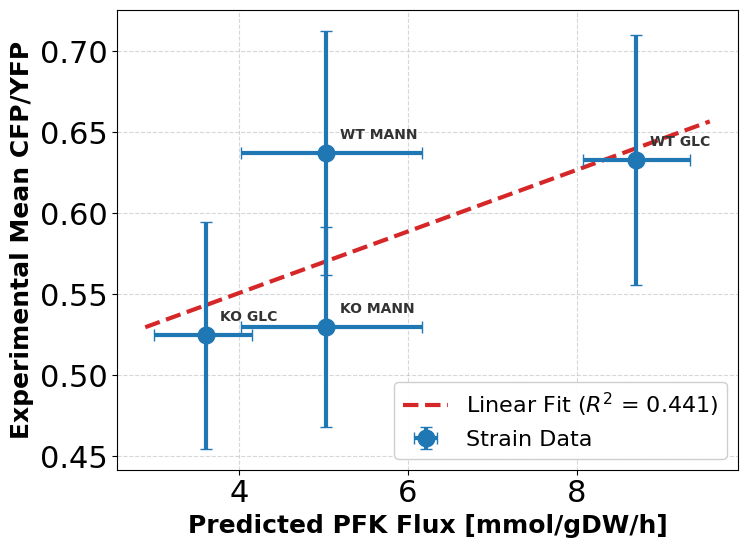

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. EXTRACT DATA (Assuming 'df' and 'plot_data' are already in memory)
# =====================================================================
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# --- A. Get Proteomics Data (Y-Axis) directly from your violin data ---
# Calculate the mean and standard deviation for each strain's experimental data
prot_means = np.array([np.mean(data) for data in plot_data])
prot_errs = np.array([np.std(data) for data in plot_data])

# --- B. Get Predicted Flux Data (X-Axis) ---
anchor_method = 'tFBA regressed (7 conditions)' 
flux_means = df.loc[anchor_method, 'Value'].values
flux_upper = df.loc[anchor_method, 'Upper'].values
flux_lower = df.loc[anchor_method, 'Low'].values

# Calculate true asymmetric errors for the X-axis
all_vals = np.vstack([flux_means, flux_upper, flux_lower])
true_min = np.min(all_vals, axis=0)
true_max = np.max(all_vals, axis=0)

flux_err_lower = flux_means - true_min
flux_err_upper = true_max - flux_means
xerr = [flux_err_lower, flux_err_upper]

# =====================================================================
# 2. CALCULATE LINEAR REGRESSION & R-SQUARED
# =====================================================================
# Calculate the line of best fit (y = mx + b)
slope, intercept = np.polyfit(flux_means, prot_means, 1)

# Calculate R-squared to prove correlation
correlation_matrix = np.corrcoef(flux_means, prot_means)
r_squared = correlation_matrix[0, 1] ** 2

# =====================================================================
# 3. BUILD THE SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the points with 2D Error Bars (crosshairs)
ax.errorbar(flux_means, prot_means, xerr=xerr, yerr=prot_errs, fmt='o', 
            color='#1f77b4', capsize=4, zorder=3, label='Strain Data') #markersize=8,  capthick=1.5, elinewidth=1.5,

# Annotate each dot with its Strain Name so you know which is which
for i, txt in enumerate(strains):
    # Offset the text slightly so it doesn't overlap the dot or error bars
    ax.annotate(txt, (flux_means[i], prot_means[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=10, fontweight='bold', color='#333333')

# Plot the Trendline
# Generate x-values that span just slightly beyond your min and max flux
x_line = np.linspace(min(flux_means)*0.8, max(flux_means)*1.1, 100)
y_line = slope * x_line + intercept

# Draw the regression line
ax.plot(x_line, y_line, color='#d62728', linestyle='--', zorder=2,
        label=f'Linear Fit ($R^2$ = {r_squared:.3f})')

# =====================================================================
# 4. FORMATTING
# =====================================================================
# ax.set_title('Correlation: Predicted Flux vs. Experimental Cra Activity', fontsize=14)
ax.set_xlabel('Predicted PFK Flux [mmol/gDW/h]', fontsize=18, fontweight='bold')
ax.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP',fontsize=18, fontweight='bold')

# Ensure axes start at 0 if you want to show absolute scaling, 
# or let matplotlib auto-scale to zoom in on the cluster. 
# ax.set_xlim(left=0)
# ax.set_ylim(bottom=0)

ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.show()

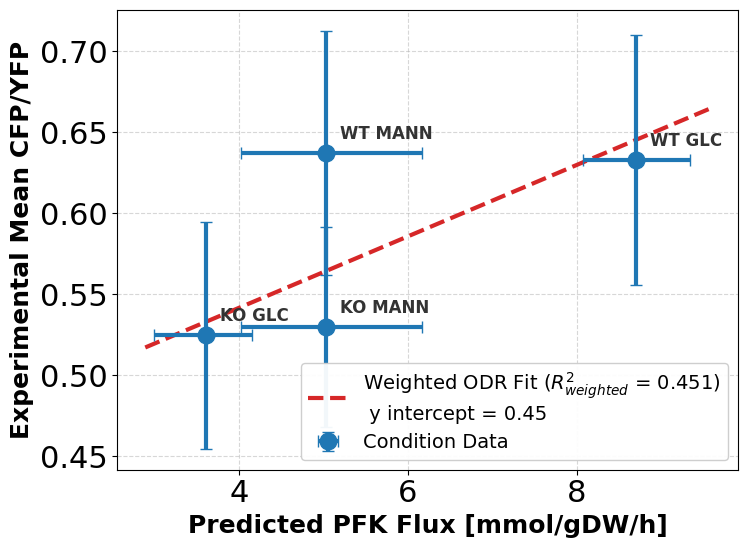

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. EXTRACT DATA (Assuming 'df' and 'plot_data' are already in memory)
# =====================================================================
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# --- A. Get Proteomics Data (Y-Axis) directly from your violin data ---
# Calculate the mean and standard deviation for each strain's experimental data
prot_means = np.array([np.mean(data) for data in plot_data])
prot_errs = np.array([np.std(data) for data in plot_data])

# --- B. Get Predicted Flux Data (X-Axis) ---
anchor_method = 'tFBA regressed (7 conditions)' 
flux_means = df.loc[anchor_method, 'Value'].values
flux_upper = df.loc[anchor_method, 'Upper'].values
flux_lower = df.loc[anchor_method, 'Low'].values

# Calculate true asymmetric errors for the X-axis
all_vals = np.vstack([flux_means, flux_upper, flux_lower])
true_min = np.min(all_vals, axis=0)
true_max = np.max(all_vals, axis=0)

flux_err_lower = flux_means - true_min
flux_err_upper = true_max - flux_means
xerr = [flux_err_lower, flux_err_upper]

import scipy.odr as odr

# =====================================================================
# 2. ODR REGRESSION (Accounts for both X and Y errors)
# =====================================================================
# For ODR, we need symmetric errors. 
# We approximate the asymmetric X-errors by taking the mean of the upper and lower bounds
x_err_sym = (flux_err_lower + flux_err_upper) / 2.0

# Define a linear function to fit: f(B, x) = B[0]*x + B[1]
def linear_func(B, x):
    return B[0] * x + B[1]

# Setup the ODR model with our data AND our errors (wd = 1/x_error^2, we = 1/y_error^2)
linear_model = odr.Model(linear_func)
mydata = odr.RealData(flux_means, prot_means, sx=x_err_sym, sy=prot_errs)
myodr = odr.ODR(mydata, linear_model, beta0=[1.0, 1.0])

# Run the regression
myoutput = myodr.run()
slope, intercept = myoutput.beta

# Calculate a Weighted R-squared (pseudo-R2 for ODR)
# This compares the variance of the fit against the variance of the data, weighted by the Y-errors
residuals = prot_means - (slope * flux_means + intercept)
ss_res = np.sum((residuals / prot_errs)**2)
ss_tot = np.sum(((prot_means - np.mean(prot_means)) / prot_errs)**2)
weighted_r_squared = 1 - (ss_res / ss_tot)

# =====================================================================
# 3. BUILD THE SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(flux_means, prot_means, xerr=xerr, yerr=prot_errs, fmt='o', 
            color='#1f77b4',  capsize=4, zorder=3, label='Condition Data')

for i, txt in enumerate(strains):
    ax.annotate(txt, (flux_means[i], prot_means[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize = 12, fontweight='bold', color='#333333')

# Plot the ODR Trendline
x_line = np.linspace(min(flux_means)*0.8, max(flux_means)*1.1, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='#d62728', linestyle='--', zorder=2,
        label=f'Weighted ODR Fit ($R^2_{{weighted}}$ = {weighted_r_squared:.3f})\n y intercept = {intercept:.2f}')

# =====================================================================
# 4. FORMATTING
# =====================================================================
# ax.set_title('Correlation: Predicted Flux vs. Experimental Cra Activity', fontsize=14)
ax.set_xlabel('Predicted PFK Flux [mmol/gDW/h]', fontsize=18, fontweight='bold')
ax.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP', fontsize=18, fontweight='bold')

# Ensure axes start at 0 if you want to show absolute scaling, 
# or let matplotlib auto-scale to zoom in on the cluster. 
# ax.set_xlim(left=0)
# ax.set_ylim(bottom=0)

ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax.legend(loc='lower right',fontsize=14, framealpha=0.95)

plt.tight_layout()

plt.savefig('/Users/eduardmrug/Downloads/EcoliPoster/ODR_me.pdf', format="pdf", bbox_inches="tight")
plt.show()

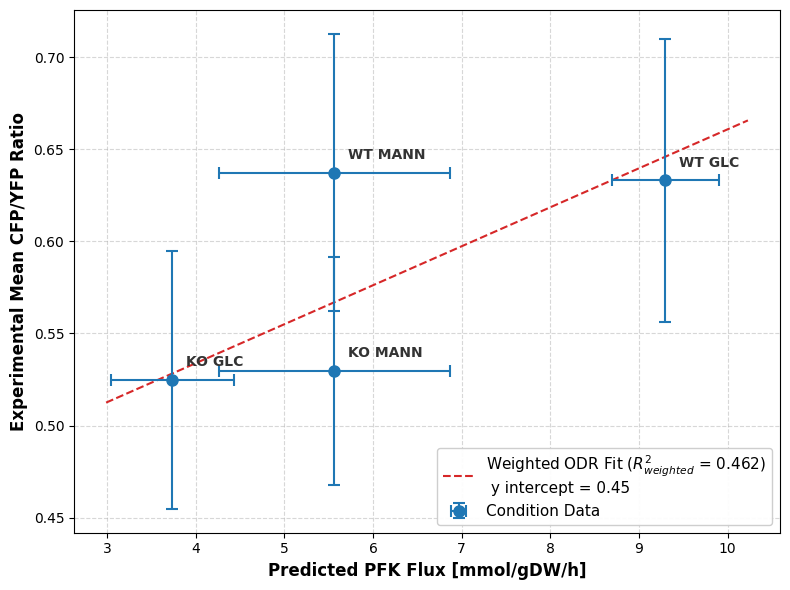

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. EXTRACT DATA (Assuming 'df' and 'plot_data' are already in memory)
# =====================================================================
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# --- A. Get Proteomics Data (Y-Axis) directly from your violin data ---
# Calculate the mean and standard deviation for each strain's experimental data
prot_means = np.array([np.mean(data) for data in plot_data])
prot_errs = np.array([np.std(data) for data in plot_data])

# --- B. Get Predicted Flux Data (X-Axis) ---
anchor_method = 'FBA' 
flux_means = df.loc[anchor_method, 'Value'].values
flux_upper = df.loc[anchor_method, 'Upper'].values
flux_lower = df.loc[anchor_method, 'Low'].values

# Calculate true asymmetric errors for the X-axis
all_vals = np.vstack([flux_means, flux_upper, flux_lower])
true_min = np.min(all_vals, axis=0)
true_max = np.max(all_vals, axis=0)

flux_err_lower = flux_means - true_min
flux_err_upper = true_max - flux_means
xerr = [flux_err_lower, flux_err_upper]

import scipy.odr as odr

# =====================================================================
# 2. ODR REGRESSION (Accounts for both X and Y errors)
# =====================================================================
# For ODR, we need symmetric errors. 
# We approximate the asymmetric X-errors by taking the mean of the upper and lower bounds
x_err_sym = (flux_err_lower + flux_err_upper) / 2.0

# Define a linear function to fit: f(B, x) = B[0]*x + B[1]
def linear_func(B, x):
    return B[0] * x + B[1]

# Setup the ODR model with our data AND our errors (wd = 1/x_error^2, we = 1/y_error^2)
linear_model = odr.Model(linear_func)
mydata = odr.RealData(flux_means, prot_means, sx=x_err_sym, sy=prot_errs)
myodr = odr.ODR(mydata, linear_model, beta0=[1.0, 1.0])

# Run the regression
myoutput = myodr.run()
slope, intercept = myoutput.beta

# Calculate a Weighted R-squared (pseudo-R2 for ODR)
# This compares the variance of the fit against the variance of the data, weighted by the Y-errors
residuals = prot_means - (slope * flux_means + intercept)
ss_res = np.sum((residuals / prot_errs)**2)
ss_tot = np.sum(((prot_means - np.mean(prot_means)) / prot_errs)**2)
weighted_r_squared = 1 - (ss_res / ss_tot)

# =====================================================================
# 3. BUILD THE SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(flux_means, prot_means, xerr=xerr, yerr=prot_errs, fmt='o', 
            color='#1f77b4', markersize=8, capsize=4, capthick=1.5, 
            elinewidth=1.5, zorder=3, label='Condition Data')

for i, txt in enumerate(strains):
    ax.annotate(txt, (flux_means[i], prot_means[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=10, fontweight='bold', color='#333333')

# Plot the ODR Trendline
x_line = np.linspace(min(flux_means)*0.8, max(flux_means)*1.1, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='#d62728', linestyle='--', zorder=2,
        label=f'Weighted ODR Fit ($R^2_{{weighted}}$ = {weighted_r_squared:.3f})\n y intercept = {intercept:.2f}')

# =====================================================================
# 4. FORMATTING
# =====================================================================
# ax.set_title('Correlation: Predicted Flux vs. Experimental Cra Activity', fontsize=14)
ax.set_xlabel('Predicted PFK Flux [mmol/gDW/h]', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Experimental {data_type.capitalize()} CFP/YFP Ratio', fontsize=12, fontweight='bold')

# Ensure axes start at 0 if you want to show absolute scaling, 
# or let matplotlib auto-scale to zoom in on the cluster. 
# ax.set_xlim(left=0)
# ax.set_ylim(bottom=0)

ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

## Legacy regressions

They can not fit concentrations

In [49]:
# ==========================================
# PHASE 2: THE 6-CONDITION HAIL MARY
# ==========================================
conds_6 = ['WT-Ace_I','WT-Fruc_I','WT-Fum_I','WT-Glyc_I','WT-Pyr_I','WT-Succ_I']

# YOU MUST REBUILD THE MODEL FROM SCRATCH HERE
tmodel.m = None


# 1. Define lists of things that need condition-specific clamping
all_carbon_sources = [
    'EX_glc__D_e', 'EX_ac_e', 'EX_fru_e', 'EX_succ_e', 
    'EX_fum_e', 'EX_glyc_e', 'EX_man__D_e', 'EX_pyr_e'
]

all_acid_exchanges = [
    'EX_mal__L_e', 'EX_fum_e', 'EX_succ_e', 
    'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e'
]

# Combine them for the clamping loop to be clean
all_elective_exchanges = list(set(all_carbon_sources + all_acid_exchanges))

acid_transporter_map = {
    'EX_mal__L_e': 'MALt2_2',
    'EX_fum_e': 'FUMt2_2',
    'EX_succ_e': 'SUCCt2_2', 
    'EX_lac__D_e': 'D_LACt2',
    'EX_pyr_e': 'PYRt2',
    'EX_ac_e': 'ACt2r'
}

# =====================================================================
# THE MISSING GENERAL OPENING: Open base bounds before TFBA generation
# =====================================================================

# Open all elective exchanges globally in the base model
for rxn_id in all_elective_exchanges:
    if rxn_id in tmodel.reactions:
        tmodel.reactions.get_by_id(rxn_id).bounds = (-1000.0, 1000.0)

# Open the internal transporters ONLY for conditions where the acid is measured
for cond_name in conds_6:
    active_rxns = df_filtered[df_filtered['cond'] == cond_name]['rxn'].tolist()
    for ex_rxn, transport_rxn in acid_transporter_map.items():
        if ex_rxn in active_rxns and transport_rxn in tmodel.reactions:
            tmodel.reactions.get_by_id(transport_rxn).bounds = (-1000.0, 1000.0)

# Catch the Core model quirk for Succinate
if 'EX_succ_e' in df_filtered['rxn'].values and 'SUCCt3' in tmodel.reactions:
    tmodel.reactions.get_by_id('SUCCt3').bounds = (-1000.0, 1000.0)

# =====================================================================

# 2. Generate the TFBA variables using the newly opened bounds
tmodel.add_TFBA_variables(conds = conds_6, gdiss_constraint = False, error_type='covariance') 

v = tmodel.mvars['v'] 
reaction_ids = [rxn.id for rxn in tmodel.reactions]

# 3. Clamp inactive sources AND unmeasured acids to 0 directly in Gurobi
for cond_index, cond_name in enumerate(conds_6):
    active_rxns = df_filtered[df_filtered['cond'] == cond_name]['rxn'].tolist()
    
    for ex_rxn in all_elective_exchanges:
        if ex_rxn in tmodel.reactions and ex_rxn not in active_rxns:
            # If it's not the active carbon source, AND it wasn't measured 
            # as a secreted byproduct, we lock the exchange to 0.
            rxn_idx = reaction_ids.index(ex_rxn)
            v[cond_index, rxn_idx].lb = 0
            v[cond_index, rxn_idx].ub = 0

# Apply the clamping changes to the Gurobi backend
tmodel.m.update()
# Extract the new qm variable pointer


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10


In [50]:
#add regression constraint to this TFBA model 
tmodel.regression(conds_6,
                  flux_data=df_indexed, #provide the experimental data as a dataframe indexed by condition and reaction
                  metabolite_data=None, 
                  volume_data=None,
                  conc_fit=False,
                  error_type = 'covariance', 
                  flux_fit=True, #fit to the flux data 
                  drG_fit=True,  # optional, minimise the drG errors to make the drG0prime close to the mean values 
                  resnorm=2) #the norm to use for the regression 1: L1 norm (sum of absolute differences), 2: L2 norm (sum of squared differences)

In [51]:
qm_new = tmodel.mvars['qm']

# 1. Inject the Warm Start
for i in range(len(successful_qm)):
    qm_new[i].Start = successful_qm[i]



In [52]:
# 2. Apply the "Desperation" Heuristics
tmodel.m.Params.MIPFocus = 1         # Focus strictly on finding feasible solutions
tmodel.m.Params.Heuristics = 0.5     # Spend 50% of time jumping around for quick answers
tmodel.m.Params.TimeLimit = 120    # Hard stop at 1.5
tmodel.m.optimize()

Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.5
Set parameter TimeLimit to value 120
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  120
Heuristics  0.5
MIPFocus  1
NonConvex  2

Optimize a model with 5953 rows, 5143 columns and 23362 nonzeros
Model fingerprint: 0x7db6eb6b
Model has 59 quadratic objective terms
Model has 31 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 4417 continuous, 726 integer (726 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [2e-02, 2e+04]
  QLMatrix range   [1e+00, 2e+04]
  Objective range  [1e+00, 1e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [1e-05, 1e+08]
  RHS range        [1e-14, 1e+08]
  QRHS range       [2e+01, 5e+03]
         Consider reformulating model or setting Nume

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# function for plotting the results of flux regression 
def reg_flux_plot(tmodel, flux_data, conds):
    mvars = tmodel.mvars

    mean_flux = flux_data.loc[conds].unstack(level=0)['mean']
    mean_flux = mean_flux.fillna(0)
    sd=flux_data.loc[conds].unstack(level=0)['sd']

    #get flux solution 
    flux_df = pd.DataFrame(mvars['v'].getAttr("x")).T
    flux_df['rxn_id'] = [rxn.id for rxn in tmodel.reactions]
    flux_df = flux_df.set_index('rxn_id')

    fitted_flux = flux_df.loc[mean_flux.index]
    fitted_flux.columns = conds

    sns.set(rc={"figure.dpi":100})
    sns.set_theme(style="whitegrid", palette=None)

    df = pd.concat([mean_flux, fitted_flux,sd], keys = ['mean', 'fitted','sd'], axis=0).unstack(level=1).T.reset_index()
    g= sns.lmplot( x="mean", y="fitted", data=df, col='rxn', legend=False, height=5, aspect=1, facet_kws={'sharex':False, 'sharey':False}, hue='level_0',col_wrap=4)

    # make sure all the axis are square 
    for ax in g.axes:
        ax.set_aspect('equal')
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        ax.set_xlim(min(xmin,ymin),max(xmax,ymax))
        ax.set_ylim(min(xmin,ymin),max(xmax,ymax))

        ax.legend()
    pd.set_option('display.max_rows', 5000)
    df['residual'] = abs((df['fitted'] - df['mean']))
    df['L2_residual'] = (df['fitted'] - df['mean'])**2

    df.index=df['level_0']+'_'+df['rxn']
    df = df.sort_values(by='residual', ascending=False)

    return df, g


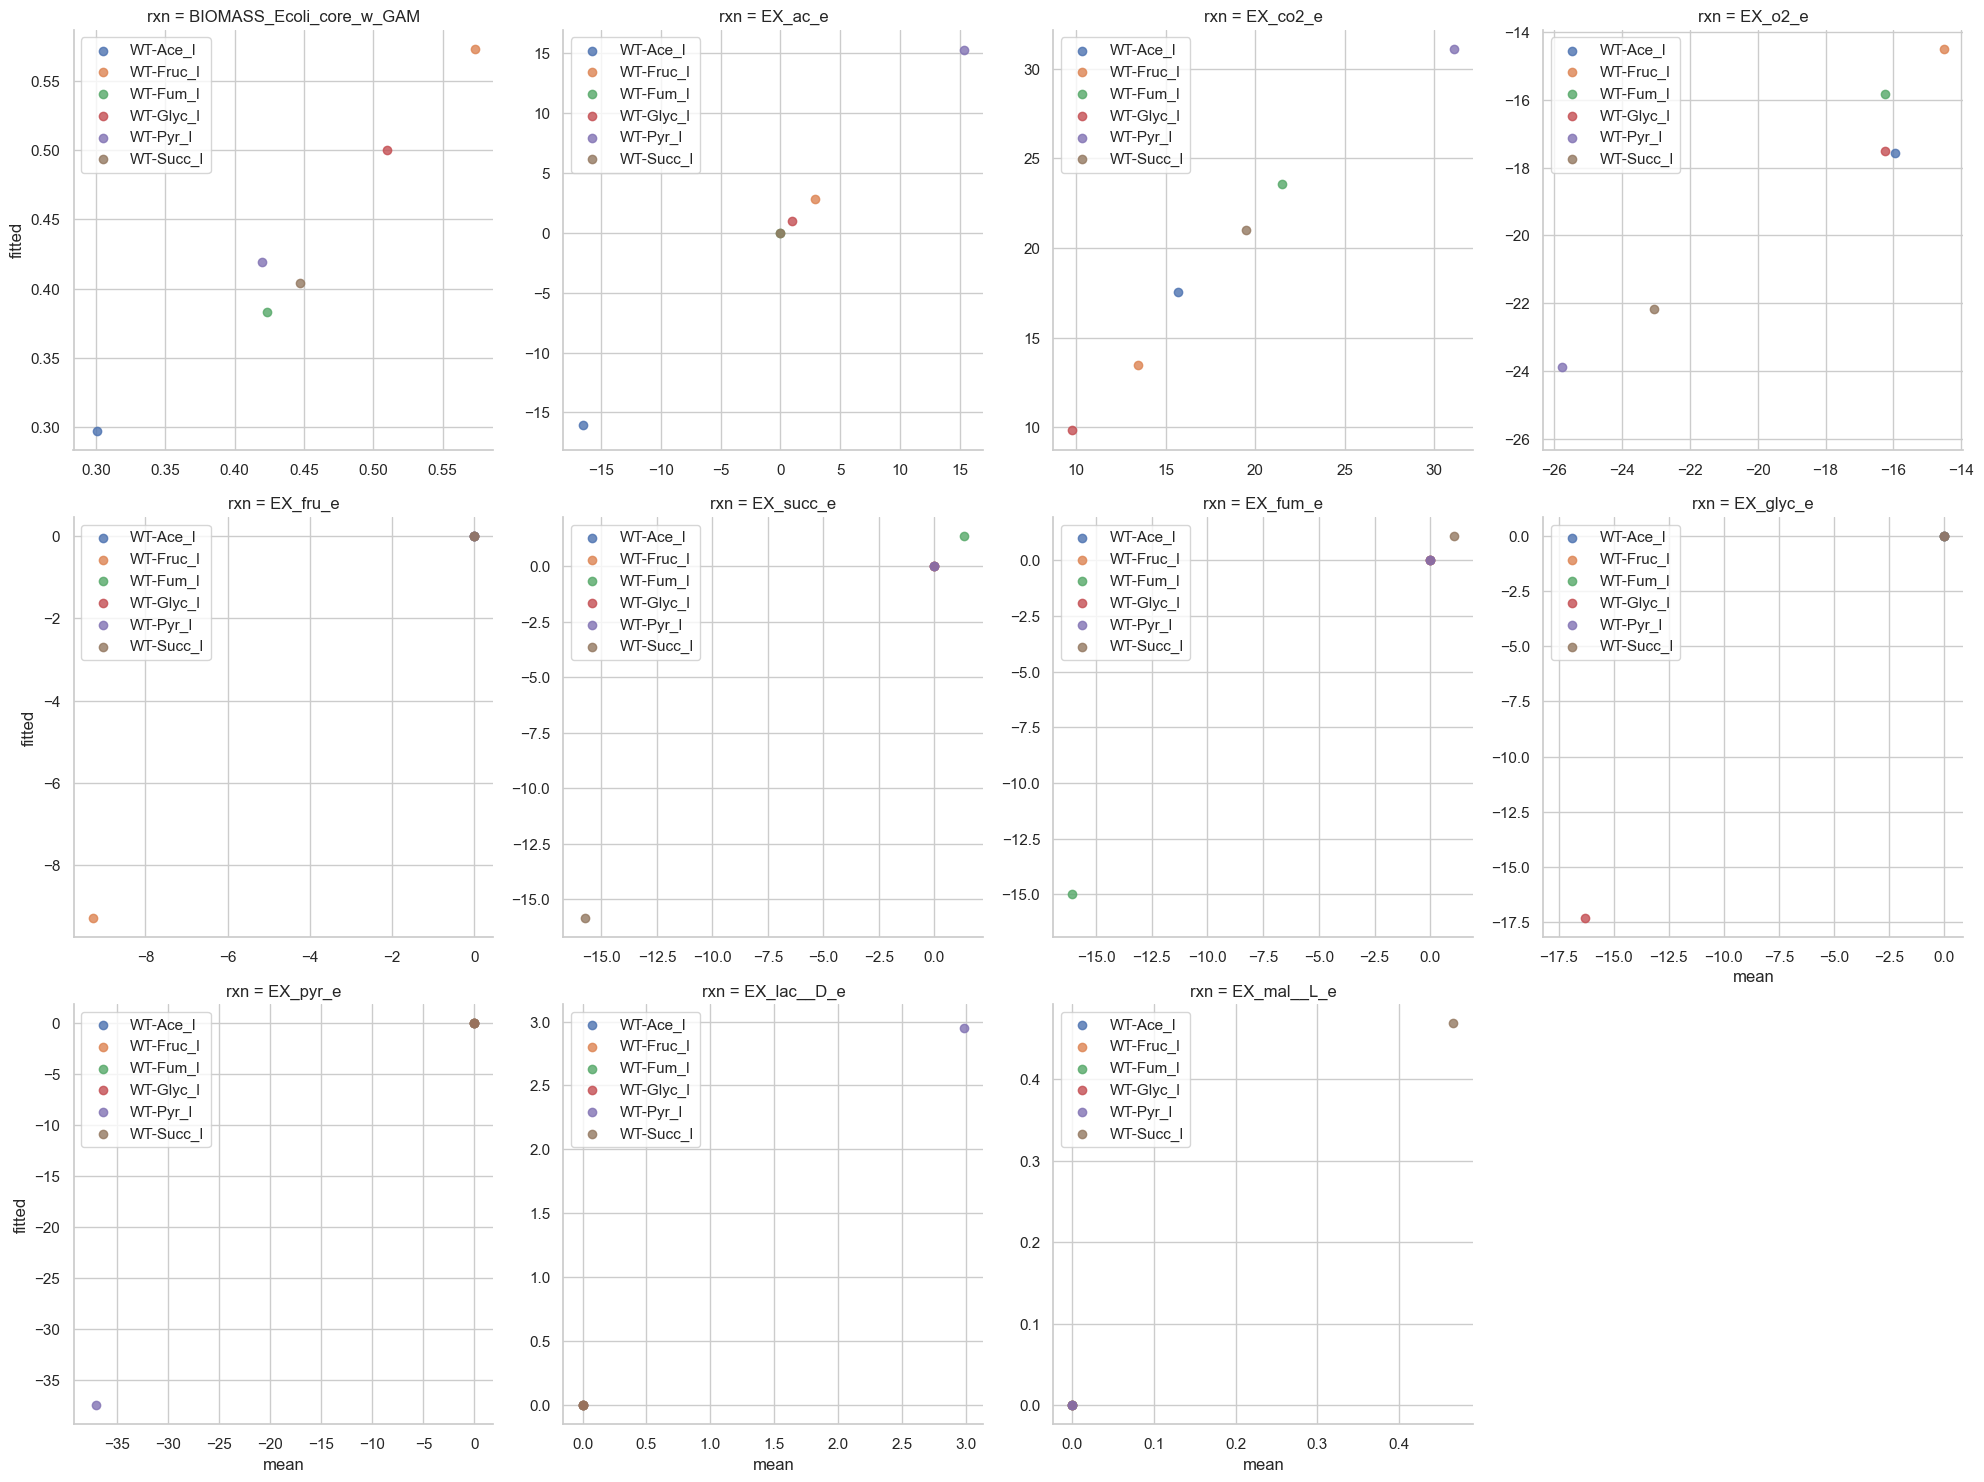

In [31]:
flux_reg, g = reg_flux_plot(tmodel, df_indexed, conds_6)

In [50]:
# 1. Check the direction (Minimize vs Maximize)
sense = tmodel.m.ModelSense
if sense == 1:
    print("Direction: MINIMIZE")
elif sense == -1:
    print("Direction: MAXIMIZE")

# 2. Print the actual math equation of the objective
obj_expr = tmodel.m.getObjective()
print("\nObjective Equation:")
print(obj_expr)

Direction: MINIMIZE

Objective Equation:
resflx[0,0] + resflx[0,1] + resflx[0,2] + resflx[0,3] + resflx[0,4] + resflx[0,5] + resflx[0,6] + resflx[0,7] + resflx[0,8] + resflx[0,9] + resflx[0,10] + resflx[0,11] + resflx[0,12] + resflx[0,13] + resflx[1,0] + resflx[1,1] + resflx[1,2] + resflx[1,3] + resflx[1,4] + resflx[1,5] + resflx[1,6] + resflx[1,7] + resflx[1,8] + resflx[1,9] + resflx[1,10] + resflx[1,11] + resflx[1,12] + resflx[1,13] + resflx[2,0] + resflx[2,1] + resflx[2,2] + resflx[2,3] + resflx[2,4] + resflx[2,5] + resflx[2,6] + resflx[2,7] + resflx[2,8] + resflx[2,9] + resflx[2,10] + resflx[2,11] + resflx[2,12] + resflx[2,13] + resflx[3,0] + resflx[3,1] + resflx[3,2] + resflx[3,3] + resflx[3,4] + resflx[3,5] + resflx[3,6] + resflx[3,7] + resflx[3,8] + resflx[3,9] + resflx[3,10] + resflx[3,11] + resflx[3,12] + resflx[3,13] + resflx[4,0] + resflx[4,1] + resflx[4,2] + resflx[4,3] + resflx[4,4] + resflx[4,5] + resflx[4,6] + resflx[4,7] + resflx[4,8] + resflx[4,9] + resflx[4,10] + resf

In [33]:
# # Run the IIS calculation
# tmodel.m.computeIIS()

# print("\n--- CONFLICTING VARIABLE BOUNDS ---")
# # Loop through all variables in the gurobi model
# for v in tmodel.m.getVars():
#     # If the Lower Bound is part of the problem
#     if v.IISLB > 0:
#         print(f"Conflicting Lower Bound: {v.VarName} (Current LB: {v.lb})")
#     # If the Upper Bound is part of the problem
#     if v.IISUB > 0:
#         print(f"Conflicting Upper Bound: {v.VarName} (Current UB: {v.ub})")

# print("\n--- CONFLICTING CONSTRAINTS ---")
# # Loop through constraints just in case it's a mass balance issue
# for c in tmodel.m.getConstrs():
#     if c.IISConstr > 0:
#         print(f"Conflicting Constraint: {c.ConstrName}")

In [51]:
qm_fitted = tmodel.mvars['qm'].X

# Prediction tests

In [ ]:
from gurobipy import GRB
# 1. Close the Alternative Carbon Buffet
alternative_exchanges = [
    'EX_ac_e', 'EX_fru_e', 'EX_succ_e', 
    'EX_fum_e', 'EX_glyc_e', 'EX_pyr_e', 
    'EX_mal__L_e', 'EX_lac__D_e', 'EX_for_e'
]

for rxn_id in alternative_exchanges:
    if rxn_id in tmodel.reactions:
        # 0.0 lower bound means NO UPTAKE. 
        # 1000.0 upper bound means SECRETION is still allowed.
        tmodel.reactions.get_by_id(rxn_id).bounds = (0.0, 1000.0)

# Ensure normal M9 default bounds for oxygen (if not already set)
tmodel.reactions.EX_o2_e.lower_bound = -1000.0
tmodel.reactions.ATPM.lower_bound = 8.39

tmodel.m = None #reset the gurobi model object in case you're re-running this cell
tmodel.add_TFBA_variables(gdiss_constraint = True, error_type='covariance')
tmodel.mvars['qm'].lb = qm_fitted
tmodel.mvars['qm'].ub = qm_fitted
biomass_idx = tmodel.reactions.index('biomass_EX')
biomass_v = tmodel.mvars['v'][0, biomass_idx]
tmodel.m.setObjective(biomass_v, GRB.MAXIMIZE)

tmodel.m.update() #update the model with the new bounds


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10


In [53]:
bounds_list = [[(0,1000),(-10.7,-10.7),(0,0)],
               [(0,0),(-4.3,-4.3),(0,0)],
               [(0,1000),(0,0),(-6.4,-6.4)],
               [(0,0),(0,0),(-6.4,-6.4)]
]
qm = None   # Let WT glc determine qm and fix for the others 

pfk_reg_cov = []
for i,bound in enumerate(bounds_list):
    pfk_core_run, pfk_cov_run, qm = non_regressed(tmodel,bound,qm = qm_fitted,error_type='covariance')
    
    pfk_reg_cov.append(pfk_cov_run[0])

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 150
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  150
NonConvex  2

Optimize a model with 1094 rows, 1020 columns and 7058 nonzeros
Model fingerprint: 0x832f70a5
Model has 25 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 899 continuous, 121 integer (121 binary)
Coefficient statistics:
  Matrix range     [1e-05, 1e+08]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-03, 1e+08]
  RHS range        [1e-14, 1e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 633 rows and 626 columns
Presolve time: 0.00s
Presolved: 521 rows,

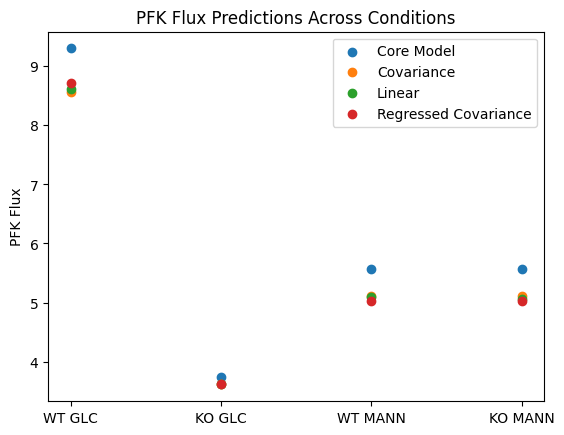

In [54]:
plt.scatter(range(4),pfk_core,label='Core Model')
plt.scatter(range(4),pfk_cov,label='Covariance')
plt.scatter(range(4),pfk_lin,label='Linear')
plt.scatter(range(4),pfk_reg_cov,label='Regressed Covariance')
plt.xticks(range(4), ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN'])
plt.ylabel('PFK Flux')
plt.title('PFK Flux Predictions Across Conditions')
plt.legend()
plt.show()

In [ ]:
def cond(tmodel,glc = True, wt = True):
    if glc:
        tmodel.reactions.EX_man__D_e.lower_bound = 0
    else:
        tmodel.reactions.EX_glc__D_e.lower_bound = 0
    if wt:
        tmodel.reactions.GLCpts.bounds = (-100,100)
    else:
        tmodel.reactions.GLCpts.bounds = (0,0)

In [26]:
# from matplotlib import pyplot as plt
# #define a range of glucose uptake rate values to scan through 
# GUR_range =  np.linspace(0,-15, 16) 
# print(GUR_range)
# metaflux = []
# for glc in [True, False]:
#     for wt in [True, False]:
#         cond(tmodel, glc=glc, wt=wt)
#         #set up a multiscenario optimization to scan over the glucose upake rate 
#         thermo_flux.solver.gurobi.variable_scan(tmodel, GUR_range, var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.EX_glc__D_e if glc else tmodel.reactions.EX_man__D_e)])
#         thermo_flux.solver.gurobi.variable_scan(tmodel, np.zeros(16), var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.EX_man__D_e if glc else tmodel.reactions.EX_glc__D_e)])
#         # here we get the index for the glucose uptake reaction and use this to index the v
#         tmodel.m.optimize()
        
#         tfluxes = thermo_flux.solver.gurobi.multi_scenario_sol(tmodel,var = 'v') 
#         tfluxes= pd.DataFrame(tfluxes[0].T, index = [rxn.id for rxn in tmodel.reactions])
#         metaflux.append(tfluxes)
#         plt.scatter(-tfluxes.loc['EX_glc__D_e' if glc else 'EX_man__D_e'], tfluxes.loc['biomass_EX'], label = f'glc: {glc}, wt: {wt}')
# plt.xlabel('Source uptake rate (mmol/gDW/hr)')
# plt.ylabel('Biomass production rate (mmol/gDW/hr)')
# # plt.plot(np.linspace(0,15,30), np.linspace(0,15,30), 'k--', label = 'x = y')
# plt.legend()
# plt.show()
        

In [ ]:
# conditions = ['GLC_wt', 'GLC_dptsG','MAN_wt','MAN_dptsG']
# combined_fluxes = pd.concat(metaflux, keys = conditions, names = ['Condition', 'Reaction'])

In [ ]:
# combined_fluxes.to_csv('../../../final/thermo_covariance_regression_fluxes.csv')

# Report and poster figures

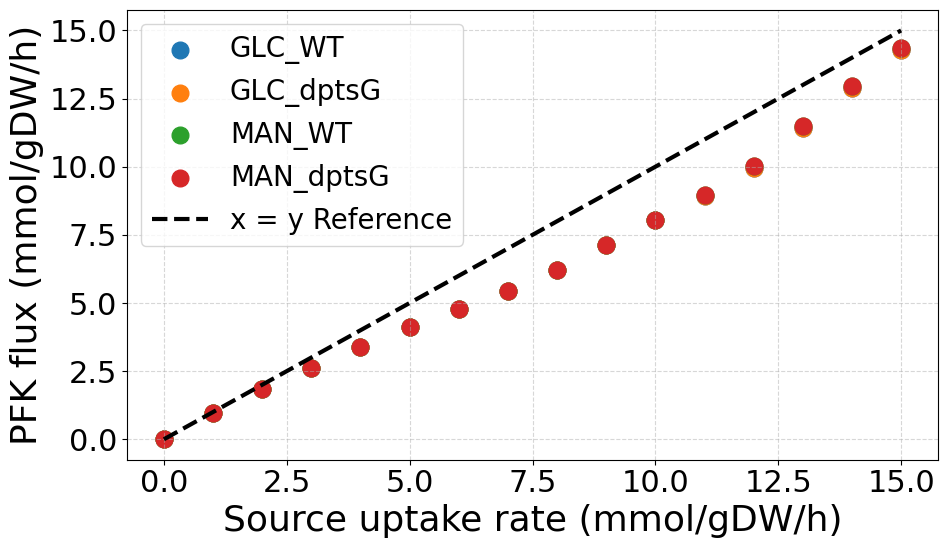

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the pre-computed dataset
# We explicitly set index_col to the two MultiIndex names saved in your file
file_path = '../../../final/thermo_covariance_regression_fluxes.csv'
df = pd.read_csv(file_path, index_col=['Condition', 'Reaction'])

# 2. Define the extraction mapping
# Matches the original loop order: (Condition Key, Uptake Reaction, Legend Label)
plot_config = [
    ('GLC_wt', 'EX_glc__D_e', 'GLC_WT'),
    ('GLC_dptsG', 'EX_glc__D_e', 'GLC_dptsG'),
    ('MAN_wt', 'EX_man__D_e', 'MAN_WT'),
    ('MAN_dptsG', 'EX_man__D_e', 'MAN_dptsG')
]

plt.figure(figsize=(10, 6))

# 3. Pull data row-by-row from the DataFrame and plot
for condition, uptake_rxn, label_name in plot_config:
    # Use tuple indexing to access rows in the MultiIndex layout
    # .to_numpy() converts the scanned scan columns into a clean 1D array
    x_data = -df.loc[(condition, uptake_rxn)].to_numpy()
    y_data = df.loc[(condition, 'PFK')].to_numpy()
    
    plt.scatter(x_data, y_data, label=label_name)

# 4. Standard Formatting and Reference Lines
plt.plot(np.linspace(0, 15, 30), np.linspace(0, 15, 30), 'k--', label='x = y Reference')
plt.xlabel('Source uptake rate (mmol/gDW/h)', fontsize=26)
plt.ylabel('PFK flux (mmol/gDW/h)', fontsize=26)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/Users/eduardmrug/Downloads/EcoliPoster/PFK_conditions.pdf", format="pdf", bbox_inches="tight")
plt.show()

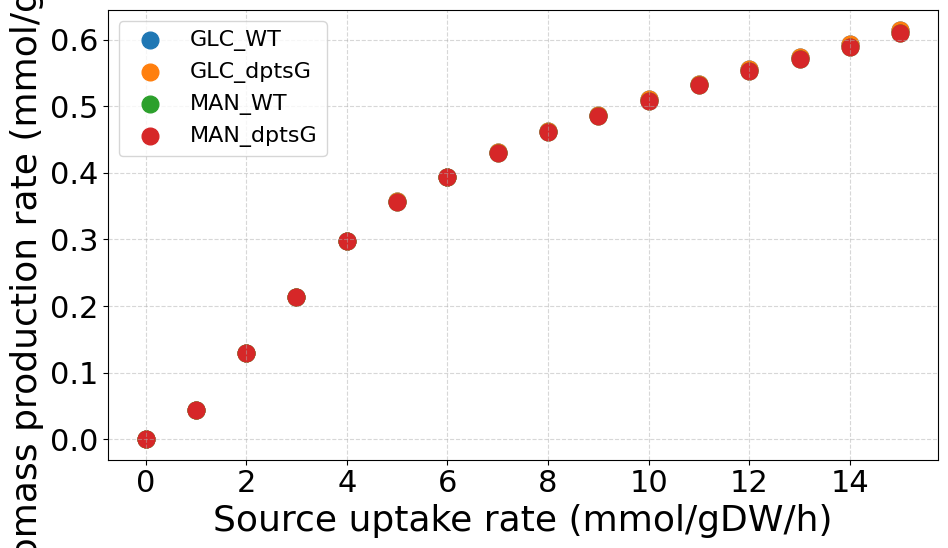

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the pre-computed dataset
# We explicitly set index_col to the two MultiIndex names saved in your file
file_path = '../../../final/thermo_covariance_regression_fluxes.csv'
df = pd.read_csv(file_path, index_col=['Condition', 'Reaction'])

# 2. Define the extraction mapping
# Matches the original loop order: (Condition Key, Uptake Reaction, Legend Label)
plot_config = [
    ('GLC_wt', 'EX_glc__D_e', 'GLC_WT'),
    ('GLC_dptsG', 'EX_glc__D_e', 'GLC_dptsG'),
    ('MAN_wt', 'EX_man__D_e', 'MAN_WT'),
    ('MAN_dptsG', 'EX_man__D_e', 'MAN_dptsG')
]

plt.figure(figsize=(10, 6))

# 3. Pull data row-by-row from the DataFrame and plot
for condition, uptake_rxn, label_name in plot_config:
    # Use tuple indexing to access rows in the MultiIndex layout
    # .to_numpy() converts the scanned scan columns into a clean 1D array
    x_data = -df.loc[(condition, uptake_rxn)].to_numpy()
    y_data = df.loc[(condition, 'biomass_EX')].to_numpy()
    
    plt.scatter(x_data, y_data, label=label_name)

# 4. Standard Formatting and Reference Lines
# plt.plot(np.linspace(0, 15, 30), np.linspace(0, 15, 30), 'k--', label='x = y')
plt.xlabel('Source uptake rate (mmol/gDW/h)')
plt.ylabel('Biomass production rate (mmol/gDW/h)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

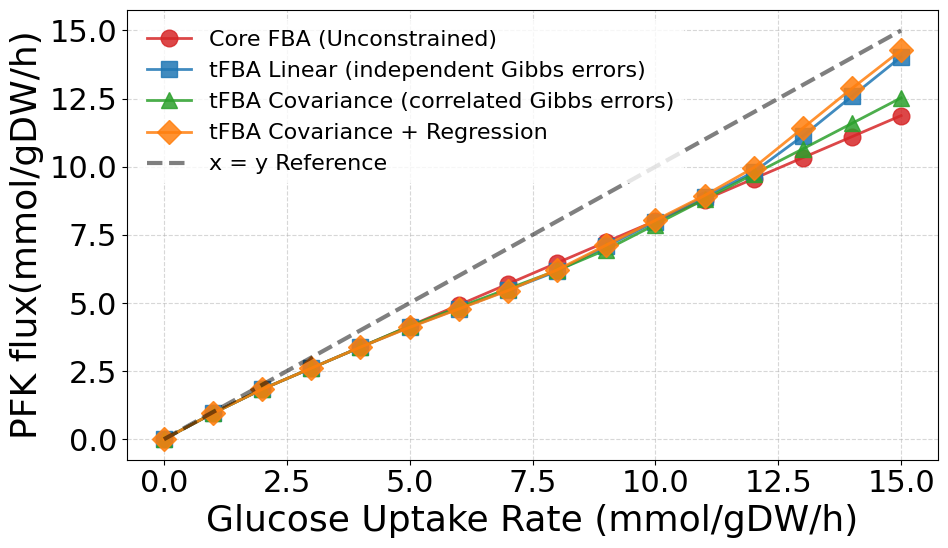

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# List of pre-computed flux CSV files to source from
files = [
    '../../../final/core_fluxes.csv',
    '../../../final/thermo_linear_fluxes.csv',
    '../../../final/thermo_covariance_fluxes.csv',
    '../../../final/thermo_covariance_regression_fluxes.csv'
]

# Formatting names for the plot legend
labels = {
    '../../../final/core_fluxes.csv': 'Core FBA (Unconstrained)',
    '../../../final/thermo_linear_fluxes.csv': 'tFBA Linear (independent Gibbs errors)',
    '../../../final/thermo_covariance_fluxes.csv': 'tFBA Covariance (correlated Gibbs errors)',
    '../../../final/thermo_covariance_regression_fluxes.csv': 'tFBA Covariance + Regression'
}

# Unique markers and colors to differentiate overlapping trends
markers = ['o', 's', '^', 'D']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

# Initialize subplots without using plt.figure() or plt.show()
fig, ax = plt.subplots(figsize=(10, 6))

for i, f in enumerate(files):
    df = pd.read_csv(f)
    
    # Filter strictly for the wild-type glucose condition
    df_glc = df[df['Condition'] == 'GLC_wt']
    
    # Extract the rows corresponding to glucose uptake and biomass production
    uptake = df_glc[df_glc['Reaction'] == 'EX_glc__D_e'].iloc[0, 2:].to_numpy().astype(float)
    biomass = df_glc[df_glc['Reaction'] == 'PFK'].iloc[0, 2:].to_numpy().astype(float)
    
    # Invert uptake rate to plot as a positive value on the X-axis
    ax.plot(-uptake, biomass, marker=markers[i], color=colors[i], 
            linestyle='-', linewidth=2,  alpha=0.85, label=labels[f])   #markersize=5,

# Add an x = y reference line for context
ax.plot(np.linspace(0, 15, 30), np.linspace(0, 15, 30), 'k--', alpha=0.5, label='x = y Reference')

# Axis styling and labelling
ax.set_xlabel('Glucose Uptake Rate (mmol/gDW/h)', fontsize=26)
ax.set_ylabel('PFK flux(mmol/gDW/h)', fontsize=26)
# ax.set_title('Impact of Thermodynamic & Regression Constraints on the Objective Function (GLC_wt)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the final figure directly to the directory
plt.savefig("/Users/eduardmrug/Downloads/EcoliPoster/PFK_constraints.pdf", format="pdf", bbox_inches="tight")

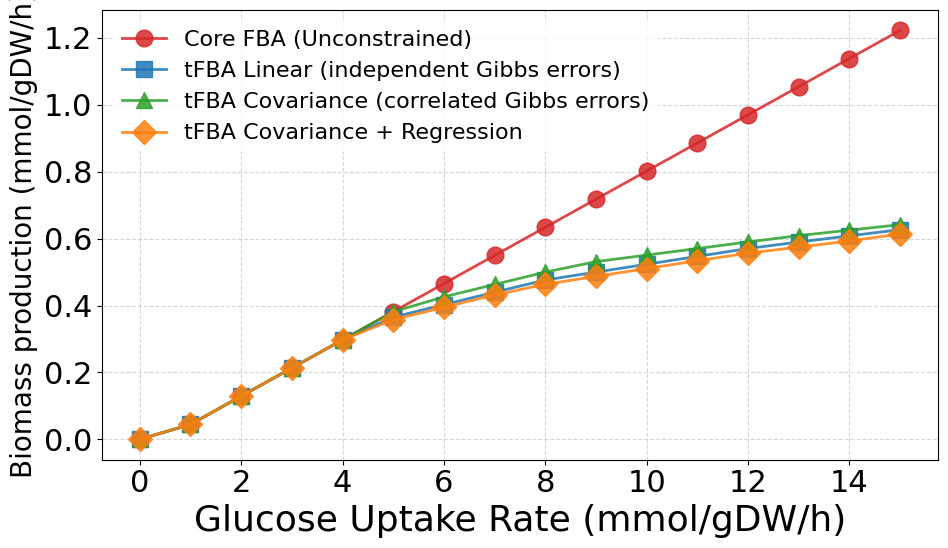

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# List of pre-computed flux CSV files to source from
files = [
    '../../../final/core_fluxes.csv',
    '../../../final/thermo_linear_fluxes.csv',
    '../../../final/thermo_covariance_fluxes.csv',
    '../../../final/thermo_covariance_regression_fluxes.csv'
]

# Formatting names for the plot legend
labels = {
    '../../../final/core_fluxes.csv': 'Core FBA (Unconstrained)',
    '../../../final/thermo_linear_fluxes.csv': 'tFBA Linear (independent Gibbs errors)',
    '../../../final/thermo_covariance_fluxes.csv': 'tFBA Covariance (correlated Gibbs errors)',
    '../../../final/thermo_covariance_regression_fluxes.csv': 'tFBA Covariance + Regression'
}

# Unique markers and colors to differentiate overlapping trends
markers = ['o', 's', '^', 'D']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

# Initialize subplots without using plt.figure() or plt.show()
fig, ax = plt.subplots(figsize=(10, 6))

for i, f in enumerate(files):
    df = pd.read_csv(f)
    
    # Filter strictly for the wild-type glucose condition
    df_glc = df[df['Condition'] == 'GLC_wt']
    
    # Extract the rows corresponding to glucose uptake and biomass production
    uptake = df_glc[df_glc['Reaction'] == 'EX_glc__D_e'].iloc[0, 2:].to_numpy().astype(float)
    biomass = df_glc[df_glc['Reaction'] == 'biomass_EX'].iloc[0, 2:].to_numpy().astype(float)
    
    # Invert uptake rate to plot as a positive value on the X-axis
    ax.plot(-uptake, biomass, marker=markers[i], color=colors[i], 
            linestyle='-', linewidth=2, alpha=0.85, label=labels[f])    # markersize=5,

# Add an x = y reference line for context
# ax.plot(np.linspace(0, 15, 30), np.linspace(0, 15, 30), 'k--', alpha=0.5, label='x = y Reference')

# Axis styling and labelling
ax.set_xlabel('Glucose Uptake Rate (mmol/gDW/h)', fontsize=26)
ax.set_ylabel('Biomass production (mmol/gDW/h)', fontsize=20)
# ax.set_title('Impact of Thermodynamic & Regression Constraints on the Objective Function (GLC_wt)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the final figure directly to the directory
plt.savefig("/Users/eduardmrug/Downloads/EcoliPoster/GR_conditions.pdf", format="pdf", bbox_inches="tight")

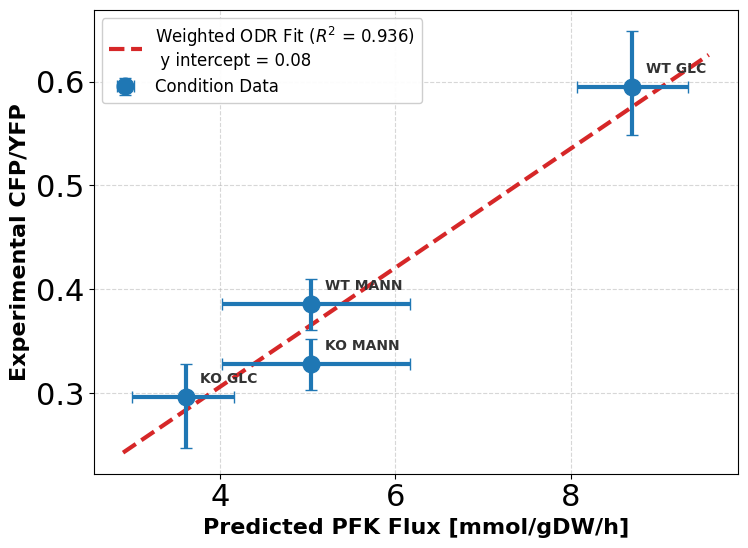

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.odr as odr

# =====================================================================
# 1. EXTRACT DATA & MANUALLY SPECIFY EXPERIMENTAL QUANTITIES
# =====================================================================
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# --- A. Manually Provide Experimental Data (Y-Axis) ---
manual_prot_means = np.array([279,139,181,154])*0.8/375 

# SPECIFY DIFFERENT ERRORS BELOW AND ABOVE FOR THE EXPERIMENT
manual_prot_low   = np.array([257, 116, 169, 142])*0.8/375 # Distance from mean to bottom of error bar
manual_prot_up    = np.array([304, 154, 192, 165])*0.8/375 # Distance from mean to top of error bar
yerr = [manual_prot_means - manual_prot_low, manual_prot_up - manual_prot_means]

# --- B. Get Predicted Flux Data (X-Axis) --

anchor_method = 'tFBA regressed (7 conditions)' 
flux_means = df.loc[anchor_method, 'Value'].values
flux_upper = df.loc[anchor_method, 'Upper'].values
flux_lower = df.loc[anchor_method, 'Low'].values

# Calculate true asymmetric errors for the X-axis
all_vals = np.vstack([flux_means, flux_upper, flux_lower])
true_min = np.min(all_vals, axis=0)
true_max = np.max(all_vals, axis=0)

flux_err_lower = flux_means - true_min
flux_err_upper = true_max - flux_means
xerr = [flux_err_lower, flux_err_upper]

# =====================================================================
# 2. ODR REGRESSION (Accounts for both X and Y errors)
# =====================================================================
# Approximate asymmetric errors with symmetric equivalents for the math engine
x_err_sym = (flux_err_lower + flux_err_upper) / 2.0
y_err_sym = (manual_prot_low + manual_prot_up) / 2.0

# Define a linear function to fit: f(B, x) = B[0]*x + B[1]
def linear_func(B, x):
    return B[0] * x + B[1]

# Setup the ODR model with our data AND our symmetric error approximations
linear_model = odr.Model(linear_func)
mydata = odr.RealData(flux_means, manual_prot_means, sx=x_err_sym, sy=y_err_sym)
myodr = odr.ODR(mydata, linear_model, beta0=[1.0, 1.0])

# Run the regression
myoutput = myodr.run()
slope, intercept = myoutput.beta

# Calculate a Weighted R-squared (pseudo-R2 for ODR) using our symmetric Y-error approximation
residuals = manual_prot_means - (slope * flux_means + intercept)
ss_res = np.sum((residuals / y_err_sym)**2)
ss_tot = np.sum(((manual_prot_means - np.mean(manual_prot_means)) / y_err_sym)**2)
weighted_r_squared = 1 - (ss_res / ss_tot)

# =====================================================================
# 3. BUILD THE SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the points with asymmetric 2D Error Bars (both xerr and yerr are now asymmetric lists)
ax.errorbar(flux_means, manual_prot_means, xerr=xerr, yerr=yerr, fmt='o', 
            color='#1f77b4',  capsize=4,  zorder=3, label='Condition Data')

# Annotate each dot with its Strain Name
for i, txt in enumerate(strains):
    ax.annotate(txt, (flux_means[i], manual_prot_means[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=10, fontweight='bold', color='#333333')

# Plot the ODR Trendline
x_line = np.linspace(min(flux_means)*0.8, max(flux_means)*1.1, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='#d62728', linestyle='--', zorder=2,
        label=f'Weighted ODR Fit ($R^2$ = {weighted_r_squared:.3f})\n y intercept = {intercept:.2f}')

# =====================================================================
# 4. FORMATTING
# =====================================================================
# ax.set_title('Correlation: Predicted Flux vs. Experimental Cra Activity', fontsize=14)
ax.set_xlabel('Predicted PFK Flux [mmol/gDW/h]',fontsize =16, fontweight='bold')
ax.set_ylabel('Experimental CFP/YFP',fontsize =16, fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax.legend(loc='upper left',fontsize=12, framealpha=0.95)

plt.tight_layout()

plt.savefig('/Users/eduardmrug/Downloads/EcoliPoster/ODR_antonia_regressed.pdf', format="pdf", bbox_inches="tight")
plt.show()

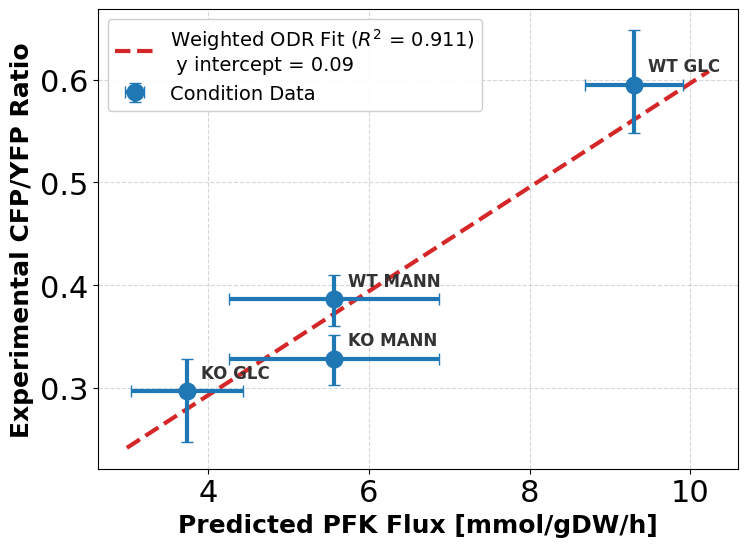

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.odr as odr

# =====================================================================
# 1. EXTRACT DATA & MANUALLY SPECIFY EXPERIMENTAL QUANTITIES
# =====================================================================
strains = ['WT GLC', 'KO GLC', 'WT MANN', 'KO MANN']

# --- A. Manually Provide Experimental Data (Y-Axis) ---
manual_prot_means = np.array([279,139,181,154])*0.8/375 

# SPECIFY DIFFERENT ERRORS BELOW AND ABOVE FOR THE EXPERIMENT
manual_prot_low   = np.array([257, 116, 169, 142])*0.8/375 # Distance from mean to bottom of error bar
manual_prot_up    = np.array([304, 154, 192, 165])*0.8/375 # Distance from mean to top of error bar
yerr = [manual_prot_means - manual_prot_low, manual_prot_up - manual_prot_means]

# --- B. Get Predicted Flux Data (X-Axis) ---
anchor_method = 'FBA' 
flux_means = df.loc[anchor_method, 'Value'].values
flux_upper = df.loc[anchor_method, 'Upper'].values
flux_lower = df.loc[anchor_method, 'Low'].values

# Calculate true asymmetric errors for the X-axis
all_vals = np.vstack([flux_means, flux_upper, flux_lower])
true_min = np.min(all_vals, axis=0)
true_max = np.max(all_vals, axis=0)

flux_err_lower = flux_means - true_min
flux_err_upper = true_max - flux_means
xerr = [flux_err_lower, flux_err_upper]

# =====================================================================
# 2. ODR REGRESSION (Accounts for both X and Y errors)
# =====================================================================
# Approximate asymmetric errors with symmetric equivalents for the math engine
x_err_sym = (flux_err_lower + flux_err_upper) / 2.0
y_err_sym = (manual_prot_low + manual_prot_up) / 2.0

# Define a linear function to fit: f(B, x) = B[0]*x + B[1]
def linear_func(B, x):
    return B[0] * x + B[1]

# Setup the ODR model with our data AND our symmetric error approximations
linear_model = odr.Model(linear_func)
mydata = odr.RealData(flux_means, manual_prot_means, sx=x_err_sym, sy=y_err_sym)
myodr = odr.ODR(mydata, linear_model, beta0=[1.0, 1.0])

# Run the regression
myoutput = myodr.run()
slope, intercept = myoutput.beta

# Calculate a Weighted R-squared (pseudo-R2 for ODR) using our symmetric Y-error approximation
residuals = manual_prot_means - (slope * flux_means + intercept)
ss_res = np.sum((residuals / y_err_sym)**2)
ss_tot = np.sum(((manual_prot_means - np.mean(manual_prot_means)) / y_err_sym)**2)
weighted_r_squared = 1 - (ss_res / ss_tot)

# =====================================================================
# 3. BUILD THE SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the points with asymmetric 2D Error Bars (both xerr and yerr are now asymmetric lists)
ax.errorbar(flux_means, manual_prot_means, xerr=xerr, yerr=yerr, fmt='o', 
            color='#1f77b4',  capsize=4, zorder=3, label='Condition Data')

# Annotate each dot with its Strain Name
for i, txt in enumerate(strains):
    ax.annotate(txt, (flux_means[i], manual_prot_means[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=12, fontweight='bold', color='#333333')

# Plot the ODR Trendline
x_line = np.linspace(min(flux_means)*0.8, max(flux_means)*1.1, 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='#d62728', linestyle='--', zorder=2,
        label=f'Weighted ODR Fit ($R^2$ = {weighted_r_squared:.3f})\n y intercept = {intercept:.2f}')

# =====================================================================
# 4. FORMATTING
# =====================================================================
# ax.set_title('Correlation: Predicted Flux vs. Experimental Cra Activity', fontsize=14)
ax.set_xlabel('Predicted PFK Flux [mmol/gDW/h]', fontsize=18, fontweight='bold')
ax.set_ylabel('Experimental CFP/YFP Ratio', fontsize=18, fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax.legend(loc='upper left', fontsize=14, framealpha=0.95)

plt.tight_layout()

plt.savefig('/Users/eduardmrug/Downloads/EcoliPoster/ODR_antonia_core.pdf', format="pdf", bbox_inches="tight")
plt.show()